# Post-Evaluation & Selection of Synthetic QUIDA Datasets

Evaluate the **12 synthetic datasets** (3 generation methods x 4 sensor combinations) produced from the
QUIDA multimodal fall-detection data, and produce a **scientifically defensible ranking** to decide which
generated dataset(s) proceed to the next research stage.

**Generation methods:** Jittering, VAE, TimeGAN
**Sensor combinations:** IMU, IMU+IR, IMU+Radar, IMU+IR+Radar

**Two clearly separated analyses (never mixed):**

* **A. Controlled-size comparison** — fair method-vs-method comparison *within each sensor combination* at a
  common synthetic sample size, repeated over many random subsamples.
* **B. Full-size evaluation** — how good each generated dataset is *at the quantity it actually provides*.

**Evaluation dimensions (grouped to avoid double-counting correlated metrics):**

* *Fidelity* — MMD (RBF), Wasserstein, multivariate Hellinger, correlation/dependency preservation.
* *Diversity / coverage* — coverage, density, nearest-neighbour diversity, variance preservation.

Scores are built hierarchically (sub-group -> category -> overall) so no dimension dominates merely by
containing more metrics.

---
### Methodological reference

El Emam K, Mosquera L, Fang X, El-Hussuna A. *Utility Metrics for Evaluating Synthetic Health Data
Generation Methods: Validation Study.* JMIR Med Inform. 2022;10(4):e35734.
[doi:10.2196/35734](https://doi.org/10.2196/35734)

This study supports the general practice of using **broad utility metrics** (including MMD, Wasserstein and
Hellinger distance) to **rank competing synthetic-data-generation methods**, and the distinction between
dataset-specific and model-specific utility. In their validation setting the **multivariate Hellinger
distance had a slight advantage for ranking** SDG methods — but MMD, Wasserstein, cluster analysis,
propensity-MSE and prediction-MSE also performed well, so Hellinger is **not** treated here as universally
dominant.

**Scope caveat:** El Emam et al. evaluated *structured health datasets* under a specific workload. It does
**not** validate any metric specifically for QUIDA, multimodal sensor time-series, or fall detection. It is
used here only as general methodological support for metric-based ranking of SDG methods.

> **Honest limitation.** The real reference sets here are small (~99 samples). With few real samples and very
> high feature dimensionality (up to ~1900 features), every metric is an *approximation*. This notebook is
> built to be explicit about representation choices and to flag statistical instability rather than hide it.

## 1. Configuration

All tunable parameters live here. Nothing about sample counts, shapes or paths is hard-coded downstream — the notebook inspects the actual files and derives the configuration from them.

In [1]:
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path.cwd()

# Synthetic/generated datasets
GENERATED_DATA_DIR = PROJECT_DIR / "generated_data"

# Real/reference datasets
REAL_DATA_DIR = PROJECT_DIR / "real_data"


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
N_REPEATS = 20


# ============================================================
# REAL DATA FILENAMES
# ============================================================

REAL_NAME_PATTERNS = [
    "{combo}_raw.npy",
    "{combo}.npy",
    "real_{combo}.npy",
    "{combo}_real.npy",
    "{combo}_original.npy",
]


# ============================================================
# METHOD / SENSOR VOCABULARY
# ============================================================

METHOD_PREFIXES = {
    "Jitter": "Jittering",
    "VAE": "VAE",
    "TimeGAN": "TimeGAN",
}

COMBO_LABELS = {
    "X_imu": "IMU",
    "X_imu_ir": "IMU+IR",
    "X_imu_radar": "IMU+Radar",
    "X_imu_ir_radar": "IMU+IR+Radar",
}


# ============================================================
# CONTROLLED SAMPLE SIZE
# ============================================================

CONTROLLED_SAMPLE_SIZE_MODE = "minimum_available"

CUSTOM_SAMPLE_SIZES = {
    # Example:
    # "X_imu": 100,
    # "X_imu_ir": 100,
    # "X_imu_radar": 100,
    # "X_imu_ir_radar": 100,
}


# ============================================================
# SMALL SAMPLE THRESHOLDS
# ============================================================

SMALL_SAMPLE_WARN = 60
SMALL_SAMPLE_MIN = 20


# ============================================================
# CATEGORY WEIGHTS
# ============================================================

CATEGORY_WEIGHTS = {
    "fidelity": 0.50,
    "diversity": 0.50,
}


# ============================================================
# QUALITY vs QUANTITY  (combined recommendation)
# ============================================================
# The headline recommendation blends size-controlled QUALITY with usable QUANTITY, so the
# winner is the best trade-off of "how good" and "how many" -- not quality alone, not size alone.
#
#   quality axis  = size-controlled overall score (fair; independent of N)
#   quantity axis = full-size sample count, passed through a DIMINISHING-RETURNS transform
#   combined      = (1 - QUANTITY_WEIGHT)*quality + QUANTITY_WEIGHT*quantity
#
# A QUALITY GATE keeps a large-but-weak dataset from winning on size alone.

QUANTITY_WEIGHT = 0.30          # weight of sample size in the combined score (quality gets 1 - this)

# how raw sample count -> quantity utility (all give diminishing returns except "linear"):
#   "saturating"        : N / (N + QUANTITY_HALF)   -- half credit at QUANTITY_HALF, plateaus after
#   "log"               : log(1 + N)
#   "linear"            : N                          -- no diminishing returns (not recommended)
#   "saturation_capped" : min(N, cap)/cap using SATURATION_N (e.g. the "recommended N" from the
#                         pre-evaluation size studies); reaching the saturation point = full credit
QUANTITY_MODE = "saturating"
QUANTITY_HALF = 300             # (saturating) N that earns half of the maximum quantity credit

# (saturation_capped) per-dataset usable-N cap; keys like "VAE_X_imu". Leave empty to ignore.
SATURATION_N = {}

# A dataset must clear this quantile of QUALITY to be eligible for the top priority tiers,
# so sample size can never rescue genuinely low-quality data (quality stays the gate).
QUALITY_GATE_QUANTILE = 0.50


# ============================================================
# METRIC / REPRESENTATION SETTINGS
# ============================================================

EMB_MAX_DIM = 30
FEAT_CAP = 200
MMD_CAP = 800
DC_K = 5
REDUNDANCY_RHO = 0.80


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

RESULTS_DIR = PROJECT_DIR / "post_evaluation_output"
FIG_DIR = RESULTS_DIR / "post_evaluation_figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 70)
print("POST-EVALUATION CONFIGURATION")
print("=" * 70)

print(f"Project dir      : {PROJECT_DIR}")
print(f"Notebook         : {PROJECT_DIR / 'QUIDA_Synthetic_PostEvaluation.ipynb'}")

print(f"\nGenerated dir    : {GENERATED_DATA_DIR}")
print(f"Generated exists : {GENERATED_DATA_DIR.exists()}")

print(f"Real data dir    : {REAL_DATA_DIR}")
print(f"Real data exists : {REAL_DATA_DIR.exists()}")

if not GENERATED_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Synthetic data directory does not exist:\n{GENERATED_DATA_DIR}"
    )

if not REAL_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Real data directory does not exist:\n{REAL_DATA_DIR}"
    )

generated_files = sorted(GENERATED_DATA_DIR.glob("*.npy"))
real_files = sorted(REAL_DATA_DIR.glob("*.npy"))

print(f"\nGenerated files  : {len(generated_files)}")
for f in generated_files:
    print(f"  - {f.name}")

print(f"\nReal .npy files  : {len(real_files)}")
for f in real_files:
    print(f"  - {f.name}")

print(f"\nResults dir      : {RESULTS_DIR}")
print(f"Figures dir      : {FIG_DIR}")

print(f"\nSEED             : {SEED}")
print(f"N_REPEATS        : {N_REPEATS}")
print(f"Sample mode      : {CONTROLLED_SAMPLE_SIZE_MODE}")

print(f"\nCategory weights : {CATEGORY_WEIGHTS}")
print(f"Quantity weight  : {QUANTITY_WEIGHT}  (mode={QUANTITY_MODE}, half={QUANTITY_HALF})")
print(f"Quality gate     : q{QUALITY_GATE_QUANTILE:.2f} of quality scores")

print("\n" + "=" * 70)

POST-EVALUATION CONFIGURATION
Project dir      : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison
Notebook         : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\QUIDA_Synthetic_PostEvaluation.ipynb

Generated dir    : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\generated_data
Generated exists : True
Real data dir    : c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\real_data
Real data exists : True

Generated files  : 12
  - Jittered_X_imu_ir_radar_synthetic_repeated_final.npy
  - Jittered_X_imu_ir_synthetic_repeated_final.npy
  - Jittered_X_imu_radar_synthetic_repeated_final.npy
  - Jittered_X_imu_synthetic_repeated_final.npy
  - TimeGAN_X_imu_ir_radar_synthetic_repeated_final.npy
  - TimeGAN_X_imu_ir_synthetic_repeated_final.npy
  - TimeGAN_X_imu_radar_synthetic_repeated_final.npy
  - TimeGAN_X_imu_synthetic_repeated_final.npy
  - VAE_X_imu_ir_radar_synthetic_repeated_final.npy
  - 

## 2. Imports

In [2]:
from __future__ import annotations
import os, json, warnings, itertools
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.covariance import LedoitWolf
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance, friedmanchisquare, kruskal, spearmanr, rankdata

np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

FIDELITY_METRICS = ["mmd", "wasserstein", "hellinger", "corr_diff"]
DIVERSITY_METRICS = ["coverage", "density", "nn_ratio", "var_diff"]
ALL_METRICS = FIDELITY_METRICS + DIVERSITY_METRICS
print("Ready. Metrics:", ALL_METRICS)

Ready. Metrics: ['mmd', 'wasserstein', 'hellinger', 'corr_diff', 'coverage', 'density', 'nn_ratio', 'var_diff']


## 3. Dataset discovery

Synthetic files are parsed as `{Method}_{comboKey}.npy`. Real files are then discovered for each combo key by searching the candidate directories with the configured name patterns. **No path is invented** — if a real file is not found the notebook stops and lists exactly where it looked.

In [3]:
def _load(p):
    return np.load(p, allow_pickle=False)

# Method-name aliases: different export namings all map to one canonical method.
# e.g. "Jittered_..." / "Jittering_..." both -> "Jitter" (fixes Jittering not being discovered).
METHOD_ALIASES = {"Jitter": ["Jittered", "Jittering", "Jitter"], "VAE": ["VAE"], "TimeGAN": ["TimeGAN"]}

def _match_method(stem):
    sl = stem.lower()
    for canon, aliases in METHOD_ALIASES.items():
        for a in sorted(aliases, key=len, reverse=True):     # longest alias first
            if sl.startswith(a.lower() + "_"):
                return canon
    return None

def _match_combo(stem):
    # pick the LONGEST known combo key that occurs in the filename, so
    # "X_imu_ir_radar" wins over the "X_imu" / "X_imu_ir" substrings it contains.
    sl = stem.lower()
    cands = [c for c in COMBO_LABELS if c.lower() in sl]
    return max(cands, key=len) if cands else None

def discover_synthetic(gen_dir):
    if not Path(gen_dir).exists():
        raise FileNotFoundError(f"GENERATED_DATA_DIR does not exist: {gen_dir}. Edit it in the config cell.")
    found, skipped = [], []
    for p in sorted(Path(gen_dir).glob("*.npy")):
        method = _match_method(p.stem); combo_key = _match_combo(p.stem)
        if method is None or combo_key is None:
            skipped.append(p.name); continue
        found.append({"path": p, "method": method, "method_label": METHOD_PREFIXES[method],
                      "combo_key": combo_key, "sensors": COMBO_LABELS.get(combo_key, combo_key)})
    if skipped:
        print("  (skipped unrecognised .npy: " + ", ".join(skipped) + ")")
    if not found:
        raise FileNotFoundError(
            f"No synthetic .npy matched method+combo in {gen_dir}. "
            f"Method aliases: {METHOD_ALIASES}; combo keys: {list(COMBO_LABELS)}")
    return found

def discover_real(combo_keys):
    search = [Path(REAL_DATA_DIR)] if REAL_DATA_DIR else list(REAL_SEARCH_DIRS)
    real = {}; missing = {}
    for ck in combo_keys:
        hit = None
        for d in search:
            if d is None or not Path(d).exists():
                continue
            for pat in REAL_NAME_PATTERNS:
                cand = Path(d) / pat.format(combo=ck)
                if cand.exists():
                    hit = cand; break
            if hit: break
        if hit: real[ck] = hit
        else:   missing[ck] = [str(Path(d) / p.format(combo=ck)) for d in search if d for p in REAL_NAME_PATTERNS]
    if missing:
        msg = ["Could not locate real data for: " + ", ".join(missing)]
        for ck, tried in missing.items():
            msg.append(f"\n  [{ck}] searched:\n    " + "\n    ".join(tried[:8]) + (" ..." if len(tried) > 8 else ""))
        msg.append("\nSet REAL_DATA_DIR or extend REAL_NAME_PATTERNS in the config cell. No path was invented.")
        raise FileNotFoundError("".join(msg))
    return real

SYNTH = discover_synthetic(GENERATED_DATA_DIR)
COMBO_KEYS = sorted({s["combo_key"] for s in SYNTH})
REAL_FILES = discover_real(COMBO_KEYS)

print(f"Discovered {len(SYNTH)} synthetic datasets across {len(COMBO_KEYS)} sensor combos.")
print("Synthetic files parsed (method | sensors):")
for s in sorted(SYNTH, key=lambda z: (z["method_label"], z["combo_key"])):
    print(f"  {s['path'].name:58s} -> {s['method_label']:9s} | {s['sensors']}")
for ck in COMBO_KEYS:
    print(f"  real[{ck:16s}] <- {REAL_FILES[ck]}")
_methods = sorted({s["method_label"] for s in SYNTH})
print("Methods found:", _methods)
if len(SYNTH) != 12:
    warnings.warn(f"Expected 12 synthetic datasets, found {len(SYNTH)}. Proceeding with what exists.")
if "Jittering" not in _methods:
    warnings.warn("Jittering not discovered — check filenames/METHOD_ALIASES.")

Discovered 12 synthetic datasets across 4 sensor combos.
Synthetic files parsed (method | sensors):
  Jittered_X_imu_synthetic_repeated_final.npy                -> Jittering | IMU
  Jittered_X_imu_ir_synthetic_repeated_final.npy             -> Jittering | IMU+IR
  Jittered_X_imu_ir_radar_synthetic_repeated_final.npy       -> Jittering | IMU+IR+Radar
  Jittered_X_imu_radar_synthetic_repeated_final.npy          -> Jittering | IMU+Radar
  TimeGAN_X_imu_synthetic_repeated_final.npy                 -> TimeGAN   | IMU
  TimeGAN_X_imu_ir_synthetic_repeated_final.npy              -> TimeGAN   | IMU+IR
  TimeGAN_X_imu_ir_radar_synthetic_repeated_final.npy        -> TimeGAN   | IMU+IR+Radar
  TimeGAN_X_imu_radar_synthetic_repeated_final.npy           -> TimeGAN   | IMU+Radar
  VAE_X_imu_synthetic_repeated_final.npy                     -> VAE       | IMU
  VAE_X_imu_ir_synthetic_repeated_final.npy                  -> VAE       | IMU+IR
  VAE_X_imu_ir_radar_synthetic_repeated_final.npy            

## 4. Dataset metadata table

Every dataset (12 synthetic + real references) is described: shape, sample count, sequence length, feature count, NaN/Inf counts and basic statistics. Nothing is reshaped here.

In [4]:
def describe(name, method, sensors, path, X, kind):
    N, T, F = (X.shape + (None, None))[:3] if X.ndim == 3 else (X.shape[0], None, None)
    return {"kind": kind, "name": name, "generator": method, "sensors": sensors,
            "file": Path(path).name, "shape": str(X.shape), "n_samples": int(X.shape[0]),
            "seq_len": int(T) if T else np.nan, "n_features": int(F) if F else np.nan,
            "n_nan": int(np.isnan(X).sum()), "n_inf": int(np.isinf(X).sum()),
            "min": float(np.nanmin(X)), "max": float(np.nanmax(X)),
            "mean": float(np.nanmean(X)), "std": float(np.nanstd(X))}

RAW_SYNTH, RAW_REAL, meta_rows = {}, {}, []
for ck in COMBO_KEYS:
    Xr = _load(REAL_FILES[ck]); RAW_REAL[ck] = Xr
    meta_rows.append(describe(f"REAL_{ck}", "REAL", COMBO_LABELS.get(ck, ck), REAL_FILES[ck], Xr, "real"))
for s in SYNTH:
    Xs = _load(s["path"]); RAW_SYNTH[(s["method"], s["combo_key"])] = Xs
    meta_rows.append(describe(f"{s['method']}_{s['combo_key']}", s["method_label"], s["sensors"],
                              s["path"], Xs, "synthetic"))

META = pd.DataFrame(meta_rows)
META.to_csv(RESULTS_DIR / "dataset_metadata.csv", index=False)
print("Sample counts differ by design — reported explicitly below.\n")
try: display(META)
except NameError: print(META.to_string(index=False))

Sample counts differ by design — reported explicitly below.



,kind,name,generator,sensors,file,shape,n_samples,seq_len,n_features,n_nan,n_inf,min,max,mean,std
0,real,REAL_X_imu,REAL,IMU,X_imu_raw.npy,"(99, 32, 3)",99,32,3,0,0,-73.3806,72.0936,1.7345,6.3463
1,real,REAL_X_imu_ir,REAL,IMU+IR,X_imu_ir_raw.npy,"(99, 32, 771)",99,32,771,0,0,-73.3806,72.0936,23.9916,2.2740
2,real,REAL_X_imu_ir_radar,REAL,IMU+IR+Radar,X_imu_ir_radar_raw.npy,"(99, 32, 1905)",99,32,1905,0,0,-73.3806,"1,522.9922",18.2452,43.0397
3,real,REAL_X_imu_radar,REAL,IMU+Radar,X_imu_radar_raw.npy,"(99, 32, 1137)",99,32,1137,0,0,-73.3806,"1,522.9922",14.3050,55.3449
4,synthetic,Jitter_X_imu_ir_radar,Jittering,IMU+IR+Radar,Jittered_X_imu_ir_radar_synthetic_repeated_fin...,"(495, 32, 1905)",495,32,1905,0,0,-74.1011,"1,526.2913",18.2448,43.0613
5,synthetic,Jitter_X_imu_ir,Jittering,IMU+IR,Jittered_X_imu_ir_synthetic_repeated_final.npy,"(594, 32, 771)",594,32,771,0,0,-73.9831,72.4496,23.9916,2.2745
6,synthetic,Jitter_X_imu_radar,Jittering,IMU+Radar,Jittered_X_imu_radar_synthetic_repeated_final.npy,"(495, 32, 1137)",495,32,1137,0,0,-73.9287,"1,526.1647",14.3049,55.3742
7,synthetic,Jitter_X_imu,Jittering,IMU,Jittered_X_imu_synthetic_repeated_final.npy,"(594, 32, 3)",594,32,3,0,0,-73.7975,72.4183,1.7338,6.3532
8,synthetic,TimeGAN_X_imu_ir_radar,TimeGAN,IMU+IR+Radar,TimeGAN_X_imu_ir_radar_synthetic_repeated_fina...,"(495, 32, 1905)",495,32,1905,0,0,-86.0517,752.6492,17.4203,40.5958
9,synthetic,TimeGAN_X_imu_ir,TimeGAN,IMU+IR,TimeGAN_X_imu_ir_synthetic_repeated_final.npy,"(693, 32, 771)",693,32,771,0,0,-92.6151,30.6055,23.9759,2.2309


## 5. Validation

For every sensor combination the real and synthetic arrays must agree on sequence length and feature count (channel ordering is assumed identical because both derive from the same preprocessing — this is stated, not silently enforced). Incompatible arrays raise an error; non-finite values are imputed with a printed notice rather than silently zeroed.

In [5]:
def clean_finite(name, X):
    nn, ni = int(np.isnan(X).sum()), int(np.isinf(X).sum())
    if nn or ni:
        F = X.shape[-1]; Xf = np.where(np.isfinite(X), X, np.nan)
        fm = np.nan_to_num(np.nanmean(Xf.reshape(-1, F), axis=0))
        ii = np.where(~np.isfinite(Xf)); Xf[ii] = np.take(fm, ii[-1])
        print(f"  ! {name}: imputed {nn} NaN / {ni} Inf with per-channel means (documented, not zeroed)")
        return Xf.astype(np.float32)
    return X.astype(np.float32)

problems = []
for ck in COMBO_KEYS:
    Xr = RAW_REAL[ck]
    if Xr.ndim != 3:
        problems.append(f"real[{ck}] is not 3-D (got {Xr.shape})"); continue
    Tr, Fr = Xr.shape[1], Xr.shape[2]
    RAW_REAL[ck] = clean_finite(f"REAL_{ck}", Xr)
    for m in METHOD_PREFIXES:
        key = (m, ck)
        if key not in RAW_SYNTH: continue
        Xs = RAW_SYNTH[key]
        if Xs.ndim != 3:
            problems.append(f"{m}_{ck} is not 3-D (got {Xs.shape})"); continue
        if Xs.shape[1] != Tr or Xs.shape[2] != Fr:
            problems.append(f"{m}_{ck} shape {Xs.shape} incompatible with real (T={Tr}, F={Fr}) — NOT reshaped")
            continue
        RAW_SYNTH[key] = clean_finite(f"{m}_{ck}", Xs)

if problems:
    raise ValueError("Validation failed (nothing silently reshaped):\n  - " + "\n  - ".join(problems))
print("\nValidation passed: real/synthetic shapes compatible per sensor combination; "
      "channel ordering assumed identical (same preprocessing).")


Validation passed: real/synthetic shapes compatible per sensor combination; channel ordering assumed identical (same preprocessing).


## 6. Real / synthetic pairing (no leakage)

Each synthetic dataset is paired **only** with the real reference of its own sensor combination — never across combinations. The real arrays are never modified.

In [6]:
PAIRS = []
for s in SYNTH:
    ck = s["combo_key"]; key = (s["method"], ck)
    if key not in RAW_SYNTH: continue
    Xs, Xr = RAW_SYNTH[key], RAW_REAL[ck]
    PAIRS.append({"name": f"{s['method']}_{ck}", "method": s["method"], "method_label": s["method_label"],
                  "combo_key": ck, "sensors": s["sensors"], "synth": Xs, "real": Xr,
                  "n_synth": int(Xs.shape[0]), "n_real": int(Xr.shape[0]),
                  "seq_len": int(Xr.shape[1]), "n_feat": int(Xr.shape[2])})
print(f"{len(PAIRS)} real/synthetic pairs (each synthetic vs its OWN-combo real reference):")
for p in PAIRS:
    print(f"  {p['name']:22s} {p['sensors']:14s} n_synth={p['n_synth']:5d}  n_real={p['n_real']:4d}  "
          f"T={p['seq_len']}  F={p['n_feat']}")

12 real/synthetic pairs (each synthetic vs its OWN-combo real reference):
  Jitter_X_imu_ir_radar  IMU+IR+Radar   n_synth=  495  n_real=  99  T=32  F=1905
  Jitter_X_imu_ir        IMU+IR         n_synth=  594  n_real=  99  T=32  F=771
  Jitter_X_imu_radar     IMU+Radar      n_synth=  495  n_real=  99  T=32  F=1137
  Jitter_X_imu           IMU            n_synth=  594  n_real=  99  T=32  F=3
  TimeGAN_X_imu_ir_radar IMU+IR+Radar   n_synth=  495  n_real=  99  T=32  F=1905
  TimeGAN_X_imu_ir       IMU+IR         n_synth=  693  n_real=  99  T=32  F=771
  TimeGAN_X_imu_radar    IMU+Radar      n_synth=  495  n_real=  99  T=32  F=1137
  TimeGAN_X_imu          IMU            n_synth=  495  n_real=  99  T=32  F=3
  VAE_X_imu_ir_radar     IMU+IR+Radar   n_synth=  297  n_real=  99  T=32  F=1905
  VAE_X_imu_ir           IMU+IR         n_synth=  396  n_real=  99  T=32  F=771
  VAE_X_imu_radar        IMU+Radar      n_synth=  297  n_real=  99  T=32  F=1137
  VAE_X_imu              IMU            n_sy

## 7. Representation & embeddings (time-series note)

These are **time-series sequences** `(N, T, F)`, not tabular rows, and for the IR/radar combinations `F` is
far larger than the number of real samples. No single representation is a complete picture of temporal
fidelity, so each metric states its representation explicitly:

* **Shared standardized-PCA embedding** (fit **once on the real data** per combo, `min(EMB_MAX_DIM, T*F, n_real-1)`
  dims): a flattened `T*F` sequence representation reduced to a stable low-dimensional space. Used by MMD,
  Hellinger, coverage, density and NN-diversity so all methods for a combo live in the *same* geometry.
* **Standardized original channels** (pooled over samples & timesteps, `(N*T, F)`, channels standardized by
  the real mean/std, wide sets sub-sampled to `FEAT_CAP` channels): used by Wasserstein, correlation and
  variance. This is a *marginal / per-channel* view and is labelled as such.

> A flattened `T*F` MMD is **not** claimed to be a complete evaluation of temporal fidelity; it is a
> distributional view over the flattened-sequence embedding. The per-channel Wasserstein/correlation view is
> explicitly marginal. Both are reported so neither is mistaken for the whole story.

In [7]:
def build_context(ck, cfg_emb=EMB_MAX_DIM, feat_cap=FEAT_CAP):
    """Precompute all REAL-side quantities once per sensor combination."""
    Xr = RAW_REAL[ck]; n_real, T, F = Xr.shape
    # (a) shared standardized-PCA embedding fit on REAL
    Rflat = Xr.reshape(n_real, -1).astype(np.float64)
    sc = StandardScaler().fit(Rflat); Rs = sc.transform(Rflat)
    k = int(min(cfg_emb, Rs.shape[1], max(2, n_real - 1)))
    solver = "randomized" if Rs.shape[1] > 500 else "full"
    pca = PCA(k, random_state=SEED, svd_solver=solver).fit(Rs) if Rs.shape[1] > k else None
    def emb(X):
        Xs = sc.transform(X.reshape(len(X), -1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    Re = emb(Xr)
    # (b) per-channel standardized view (pooled), with fixed sub-sampled channel indices
    rng = np.random.default_rng(SEED)
    idx = np.sort(rng.choice(F, size=min(feat_cap, F), replace=False))
    pooled = Xr.reshape(-1, F).astype(np.float64)
    mu = pooled.mean(0); sd = pooled.std(0); sd = np.where(sd > 1e-8, sd, 1.0)
    real_std = (pooled[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        corr_real = np.nan_to_num(np.corrcoef(real_std.T))
    var_real = real_std.var(0)
    # real-side NN scale for the diversity ratio
    nn = NearestNeighbors(n_neighbors=2).fit(Re)
    d_rr = float(nn.kneighbors(Re)[0][:, 1].mean())
    return {"ck": ck, "emb": emb, "Re": Re, "idx": idx, "mu": mu, "sd": sd,
            "corr_real": corr_real, "var_real": var_real, "d_rr": max(d_rr, 1e-12),
            "n_real": n_real, "T": T, "F": F, "k": Re.shape[1]}

CTX = {ck: build_context(ck) for ck in COMBO_KEYS}
for ck, c in CTX.items():
    print(f"  {ck:16s} embedding dim={c['k']:3d}  channels used={len(c['idx'])}/{c['F']}  n_real={c['n_real']}")

c:\Users\mabideen\AppData\Local\miniforge3\envs\globalenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


  X_imu            embedding dim= 30  channels used=3/3  n_real=99
  X_imu_ir         embedding dim= 30  channels used=200/771  n_real=99
  X_imu_ir_radar   embedding dim= 30  channels used=200/1905  n_real=99
  X_imu_radar      embedding dim= 30  channels used=200/1137  n_real=99


## 8. Metric implementations

**Fidelity (lower distance = better):**

* **MMD** — RBF kernel, median-heuristic bandwidth averaged over 3 scales, in the shared embedding. Consistent
  with the synthetic-health-data literature (El Emam et al., 2022).
* **Wasserstein** — mean 1-D (marginal) Wasserstein over sub-sampled standardized channels. Representation is
  feature-wise; documented as marginal.
* **Multivariate Hellinger** — Gaussian approximation in the shared embedding: fit shrinkage-regularised
  (Ledoit-Wolf) Gaussians to real and synthetic embeddings and use the closed-form Hellinger distance between
  two multivariate Gaussians. This is a *defensible multivariate* version; it assumes approximate Gaussianity
  in the reduced space (documented, not claimed exact).
* **Correlation difference** — Frobenius norm of (real - synthetic) channel-correlation matrices / #channels.

**Diversity / coverage:**

* **Coverage** (Naeem et al., 2020 PRDC) — fraction of real points whose k-NN real-radius ball contains >=1
  synthetic point. Higher = better.
* **Density** (PRDC) — reported raw; scored by **closeness to 1**, since density >> 1 signals pathological
  over-concentration, not quality (the spec's "use density carefully").
* **NN diversity** — ratio `mean(nearest synth->real distance) / mean(real->real NN distance)` in the
  embedding. Scored by **log-symmetric closeness to 1**: penalises memorisation (ratio << 1, copying real
  points) *and* off-manifold drift (ratio >> 1). Direction and normalisation documented.
* **Variance preservation** — mean over channels of `|var_synth - var_real|` on the real-standardised scale.
  Lower = better (preservation, not maximisation).

In [8]:
def mmd_rbf(Re, Se, rng, cap=MMD_CAP):
    X = Re[rng.choice(len(Re), min(cap, len(Re)), replace=False)]
    Y = Se[rng.choice(len(Se), min(cap, len(Se)), replace=False)]
    med = np.median(cdist(X[:200], X[:200])); med = med if med > 0 else 1.0
    vals = [rbf_kernel(X, X, g/med**2).mean() + rbf_kernel(Y, Y, g/med**2).mean()
            - 2*rbf_kernel(X, Y, g/med**2).mean() for g in (0.5, 1.0, 2.0)]
    return float(max(np.mean(vals), 0.0))

def wasserstein_marginal(synth, ctx):
    idx, mu, sd = ctx["idx"], ctx["mu"], ctx["sd"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    R = (RAW_REAL[ctx["ck"]].reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    return float(np.mean([wasserstein_distance(R[:, j], S[:, j]) for j in range(R.shape[1])]))

def hellinger_gauss(Re, Se):
    if len(Se) <= Re.shape[1] + 2:                        # too few points for a stable covariance
        return np.nan
    m1, m2 = Re.mean(0), Se.mean(0)
    S1 = LedoitWolf().fit(Re).covariance_; S2 = LedoitWolf().fit(Se).covariance_
    Sm = 0.5*(S1 + S2)
    (_, ld1), (_, ld2), (_, ldm) = np.linalg.slogdet(S1), np.linalg.slogdet(S2), np.linalg.slogdet(Sm)
    try: quad = 0.125 * (m1-m2) @ np.linalg.solve(Sm, (m1-m2))
    except np.linalg.LinAlgError: return np.nan
    log_bc = 0.25*ld1 + 0.25*ld2 - 0.5*ldm - quad
    bc = float(np.clip(np.exp(log_bc), 0.0, 1.0))
    return float(np.sqrt(max(1.0 - bc, 0.0)))             # in [0,1], lower better

def corr_difference(synth, ctx):
    idx, mu, sd, Cr = ctx["idx"], ctx["mu"], ctx["sd"], ctx["corr_real"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        Cs = np.nan_to_num(np.corrcoef(S.T))
    return float(np.linalg.norm(Cr - Cs) / Cr.shape[0])

def coverage_density(Re, Se, k=DC_K):
    k = min(k, len(Re) - 1)
    radii = NearestNeighbors(n_neighbors=k+1).fit(Re).kneighbors(Re)[0][:, k]
    D = cdist(Se, Re)                                     # (n_synth, n_real)
    inside = D <= radii[None, :]
    coverage = float(inside.any(axis=0).mean())          # fraction of real covered
    density  = float(inside.sum() / (k * len(Se)))       # PRDC density
    return coverage, density

def nn_ratio(Re, Se, ctx):
    d_sr = float(cdist(Se, Re).min(axis=1).mean())       # each synth -> nearest real
    return d_sr / ctx["d_rr"]

def variance_diff(synth, ctx):
    idx, mu, sd, vr = ctx["idx"], ctx["mu"], ctx["sd"], ctx["var_real"]
    S = (synth.reshape(-1, ctx["F"])[:, idx] - mu[idx]) / sd[idx]
    return float(np.mean(np.abs(S.var(0) - vr)))

def eval_all(synth, ctx, rng):
    """All 8 raw metrics for one synthetic array vs its combo's real reference."""
    n = len(synth)
    if n < SMALL_SAMPLE_MIN:
        warnings.warn(f"n_synth={n} < SMALL_SAMPLE_MIN={SMALL_SAMPLE_MIN}: returning NaN metrics (not faked).")
        return {m: np.nan for m in ALL_METRICS}
    Se = ctx["emb"](synth)
    cov, den = coverage_density(ctx["Re"], Se)
    return {"mmd": mmd_rbf(ctx["Re"], Se, rng), "wasserstein": wasserstein_marginal(synth, ctx),
            "hellinger": hellinger_gauss(ctx["Re"], Se), "corr_diff": corr_difference(synth, ctx),
            "coverage": cov, "density": den, "nn_ratio": nn_ratio(ctx["Re"], Se, ctx),
            "var_diff": variance_diff(synth, ctx)}

print("Metric functions defined:", ALL_METRICS)

Metric functions defined: ['mmd', 'wasserstein', 'hellinger', 'corr_diff', 'coverage', 'density', 'nn_ratio', 'var_diff']


## 9. Controlled sample-size preparation & evaluation (Analysis A)

For **each sensor combination independently** the common size `N_common` is the smallest synthetic count
across the three methods (mode `minimum_available`), or a `CUSTOM_SAMPLE_SIZES` override. This is **not** a
single global size — each combination gets its own. Each method is then sub-sampled to `N_common`
(`N_REPEATS` times, different seeds); a method already at `N_common` uses all of its samples. Every metric is
summarised (mean / std / median / 95% CI) over the repeats. Sizes below `SMALL_SAMPLE_WARN` are flagged.

In [9]:
def controlled_sizes():
    sizes = {}
    for ck in COMBO_KEYS:
        counts = {m: RAW_SYNTH[(m, ck)].shape[0] for m in METHOD_PREFIXES if (m, ck) in RAW_SYNTH}
        if CONTROLLED_SAMPLE_SIZE_MODE == "custom" and ck in CUSTOM_SAMPLE_SIZES:
            n = int(CUSTOM_SAMPLE_SIZES[ck])
        else:
            n = int(min(counts.values()))
        sizes[ck] = n
        flag = "  <-- SMALL, unstable" if n < SMALL_SAMPLE_WARN else ""
        print(f"  {ck:16s} counts={counts}  ->  N_common={n}{flag}")
        if n < SMALL_SAMPLE_WARN:
            warnings.warn(f"{ck}: N_common={n} < {SMALL_SAMPLE_WARN}; controlled comparison is statistically shaky.")
    return sizes

def ci95(a):
    a = np.asarray(a, float); a = a[np.isfinite(a)]
    if len(a) < 2: return (np.nan, np.nan)
    m, s = a.mean(), a.std(ddof=1) / np.sqrt(len(a))
    return (m - 1.96*s, m + 1.96*s)

N_COMMON = controlled_sizes()

controlled_records = []          # per (method, combo, repeat) raw metrics -> stability + aggregation
for ck in COMBO_KEYS:
    n = N_COMMON[ck]; ctx = CTX[ck]
    for m in METHOD_PREFIXES:
        if (m, ck) not in RAW_SYNTH: continue
        Xs = RAW_SYNTH[(m, ck)]
        for r in range(N_REPEATS):
            rng = np.random.default_rng(SEED + r)
            take = rng.choice(len(Xs), size=min(n, len(Xs)), replace=False)
            met = eval_all(Xs[take], ctx, rng)
            controlled_records.append({"method": m, "method_label": METHOD_PREFIXES[m], "combo_key": ck,
                                       "sensors": COMBO_LABELS.get(ck, ck), "name": f"{m}_{ck}",
                                       "N_common": n, "repeat": r, **met})
CONTROLLED_RAW = pd.DataFrame(controlled_records)

# aggregate over repeats
agg = {mtr: ["mean", "std", "median"] for mtr in ALL_METRICS}
CONTROLLED_AGG = CONTROLLED_RAW.groupby(["name", "method", "method_label", "combo_key", "sensors", "N_common"]).agg(agg)
CONTROLLED_AGG.columns = [f"{a}_{b}" for a, b in CONTROLLED_AGG.columns]
CONTROLLED_AGG = CONTROLLED_AGG.reset_index()
print(f"\nControlled evaluation: {len(CONTROLLED_RAW)} rows "
      f"({len(PAIRS)} datasets x {N_REPEATS} repeats). Aggregated to {len(CONTROLLED_AGG)} datasets.")
try: display(CONTROLLED_AGG[["name","N_common"]+[f"{m}_mean" for m in ALL_METRICS]])
except NameError: pass

  X_imu            counts={'Jitter': 594, 'VAE': 396, 'TimeGAN': 495}  ->  N_common=396
  X_imu_ir         counts={'Jitter': 594, 'VAE': 396, 'TimeGAN': 693}  ->  N_common=396
  X_imu_ir_radar   counts={'Jitter': 495, 'VAE': 297, 'TimeGAN': 495}  ->  N_common=297
  X_imu_radar      counts={'Jitter': 495, 'VAE': 297, 'TimeGAN': 495}  ->  N_common=297

Controlled evaluation: 240 rows (12 datasets x 20 repeats). Aggregated to 12 datasets.


,name,N_common,mmd_mean,wasserstein_mean,hellinger_mean,corr_diff_mean,coverage_mean,density_mean,nn_ratio_mean,var_diff_mean
0,Jitter_X_imu,396,0.0006,0.0239,0.4062,0.0121,1.0000,1.0021,0.1909,0.0271
1,Jitter_X_imu_ir,396,0.0005,0.0221,0.2883,0.0134,1.0000,1.1081,0.0054,0.0265
2,Jitter_X_imu_ir_radar,297,0.0008,0.0251,0.3953,0.0086,1.0000,1.0881,0.0202,0.0270
3,Jitter_X_imu_radar,297,0.0009,0.0273,0.5466,0.0072,1.0000,1.0927,0.0285,0.0301
4,TimeGAN_X_imu,396,0.4988,0.2650,1.0000,0.3926,0.0101,0.0392,1.8096,0.5534
5,TimeGAN_X_imu_ir,396,0.0435,0.1816,0.9999,0.1818,0.9773,1.9947,1.1054,0.2761
6,TimeGAN_X_imu_ir_radar,297,0.1528,0.3100,0.9995,0.2407,0.5394,1.8089,0.8882,0.6191
7,TimeGAN_X_imu_radar,297,0.0496,0.1642,0.9910,0.2172,0.9955,1.8907,0.7441,0.4981
8,VAE_X_imu,396,0.3881,0.4261,1.0000,0.3365,0.6364,0.6601,1.5646,0.7906
9,VAE_X_imu_ir,396,0.2129,0.5120,1.0000,0.3807,0.6364,3.1662,0.8634,0.8352


## 10. Full-size evaluation (Analysis B)

Each generated dataset is evaluated **at its actual size** against its combo's real reference — a different
question from Analysis A (*how good is the dataset at the quantity it provides?*). A light bootstrap
(resampling synthetic rows) gives a stability spread. These results are kept **strictly separate** from the
controlled ones.

In [10]:
full_records, full_boot = [], []
for p in PAIRS:
    ck, ctx = p["combo_key"], CTX[p["combo_key"]]
    rng = np.random.default_rng(SEED)
    met = eval_all(p["synth"], ctx, rng)
    full_records.append({"name": p["name"], "method": p["method"], "method_label": p["method_label"],
                         "combo_key": ck, "sensors": p["sensors"], "n_synth": p["n_synth"], **met})
    for b in range(N_REPEATS):                                   # bootstrap for a stability spread
        rb = np.random.default_rng(SEED + 1000 + b)
        idx = rb.integers(0, p["n_synth"], size=p["n_synth"])
        mb = eval_all(p["synth"][idx], ctx, rb)
        full_boot.append({"name": p["name"], **mb})

FULL_RAW = pd.DataFrame(full_records)
FULL_BOOT = pd.DataFrame(full_boot)
print(f"Full-size evaluation: {len(FULL_RAW)} datasets at native sizes.")
try: display(FULL_RAW[["name","n_synth"]+ALL_METRICS])
except NameError: print(FULL_RAW.to_string(index=False))

Full-size evaluation: 12 datasets at native sizes.


,name,n_synth,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff
0,Jitter_X_imu_ir_radar,495,0.0000,0.0132,0.1944,0.0007,1.0000,1.0897,0.0202,0.0020
1,Jitter_X_imu_ir,594,0.0000,0.0043,0.1705,0.0011,1.0000,1.1077,0.0054,0.0025
2,Jitter_X_imu_radar,495,0.0000,0.0220,0.5752,0.0007,1.0000,1.0937,0.0287,0.0020
3,Jitter_X_imu,594,0.0001,0.0122,0.3712,0.0003,1.0000,1.0034,0.1907,0.0025
4,TimeGAN_X_imu_ir_radar,495,0.1527,0.3100,0.9999,0.2406,0.5556,1.8105,0.8886,0.6189
5,TimeGAN_X_imu_ir,693,0.0437,0.1803,1.0000,0.1803,0.9798,1.9850,1.1089,0.2766
6,TimeGAN_X_imu_radar,495,0.0492,0.1640,0.9977,0.2172,1.0000,1.8861,0.7406,0.4980
7,TimeGAN_X_imu,495,0.4987,0.2652,1.0000,0.3923,0.0101,0.0380,1.8100,0.5532
8,VAE_X_imu_ir_radar,297,0.2284,0.3804,1.0000,0.3581,0.3535,2.4828,0.7561,0.7002
9,VAE_X_imu_ir,396,0.2129,0.5120,1.0000,0.3807,0.6364,3.1662,0.8634,0.8352


## 11. Metric normalisation & hierarchical scoring

Every metric is first mapped to a **goodness** value (higher = better) then min-max normalised to `[0,1]`
**across the 12 datasets** of the analysis in question. Transforms (documented):

| metric | raw direction | goodness transform |
|---|---|---|
| mmd, wasserstein, hellinger, corr_diff, var_diff | lower better | `-value` |
| coverage | higher better | `value` |
| density | closeness to 1 | `-|value - 1|` |
| nn_ratio | closeness to 1 (log) | `-|ln value|` |

**Hierarchical aggregation (prevents double-counting):**

```
Fidelity  = 0.5 * mean(norm mmd, norm wasserstein, norm hellinger)   # distributional sub-group
          + 0.5 *  norm corr_diff                                    # dependency sub-group
Diversity = 0.5 * mean(norm coverage, norm density, norm nn_ratio)   # coverage/manifold sub-group
          + 0.5 *  norm var_diff                                     # variability sub-group
Overall   = w_fidelity * Fidelity + w_diversity * Diversity
```

The three correlated distributional metrics share one 50% sub-slot instead of out-voting the single
dependency metric; likewise for diversity. `NaN` metrics propagate to `NaN` scores (never coerced to 0).

In [11]:
def _goodness(col, name):
    x = np.asarray(col, float)
    if name in ("mmd", "wasserstein", "hellinger", "corr_diff", "var_diff"): return -x
    if name == "coverage": return x
    if name == "density":  return -np.abs(x - 1.0)
    if name == "nn_ratio": return -np.abs(np.log(np.clip(x, 1e-6, None)))
    raise KeyError(name)

def _minmax(g):
    g = np.asarray(g, float); ok = np.isfinite(g)
    if ok.sum() == 0: return g
    lo, hi = np.nanmin(g), np.nanmax(g)
    if hi - lo < 1e-12:
        out = np.full_like(g, 0.5); out[~ok] = np.nan; return out
    return (g - lo) / (hi - lo)

def score_table(df, metric_cols=ALL_METRICS):
    """df: one row per dataset with raw metric columns -> normalised metrics + hierarchical scores."""
    out = df.copy().reset_index(drop=True)
    norm = {}
    for m in metric_cols:
        norm[m] = _minmax(_goodness(out[m].values, m))
        out[f"n_{m}"] = norm[m]
    distributional = np.nanmean(np.vstack([norm["mmd"], norm["wasserstein"], norm["hellinger"]]), axis=0)
    dependency     = norm["corr_diff"]
    out["fidelity"] = 0.5*distributional + 0.5*dependency
    manifold   = np.nanmean(np.vstack([norm["coverage"], norm["density"], norm["nn_ratio"]]), axis=0)
    variability = norm["var_diff"]
    out["diversity"] = 0.5*manifold + 0.5*variability
    out["overall"] = (CATEGORY_WEIGHTS["fidelity"]*out["fidelity"]
                      + CATEGORY_WEIGHTS["diversity"]*out["diversity"])
    return out

# controlled means (over repeats) -> one row per dataset -> scores
ctrl_mean = CONTROLLED_AGG.rename(columns={f"{m}_mean": m for m in ALL_METRICS})[
    ["name","method","method_label","combo_key","sensors","N_common"]+ALL_METRICS]
CONTROLLED_SCORED = score_table(ctrl_mean)
FULL_SCORED = score_table(FULL_RAW)

print("Controlled-size scores (fair comparison):")
try: display(CONTROLLED_SCORED[["name","N_common","fidelity","diversity","overall"]]
             .sort_values("overall", ascending=False))
except NameError: pass

Controlled-size scores (fair comparison):


,name,N_common,fidelity,diversity,overall
0,Jitter_X_imu,396,0.9654,0.9491,0.9572
2,Jitter_X_imu_ir_radar,297,0.9720,0.8694,0.9207
1,Jitter_X_imu_ir,396,0.9920,0.8252,0.9086
3,Jitter_X_imu_radar,297,0.9376,0.8784,0.9080
5,TimeGAN_X_imu_ir,396,0.5383,0.7654,0.6518
7,TimeGAN_X_imu_radar,297,0.4983,0.6329,0.5656
6,TimeGAN_X_imu_ir_radar,297,0.3817,0.4934,0.4375
11,VAE_X_imu_radar,297,0.2099,0.4193,0.3146
8,VAE_X_imu,396,0.1390,0.4290,0.2840
10,VAE_X_imu_ir_radar,297,0.1800,0.3547,0.2674


## 12. Metric redundancy analysis

Spearman correlation of the 8 raw metrics across the 12 full-size datasets. Highly correlated pairs (`|rho| > REDUNDANCY_RHO`) are reported — the hierarchical scoring already prevents redundant distributional metrics from dominating, but this makes the redundancy explicit.

In [12]:
MET_CORR = FULL_RAW[ALL_METRICS].corr(method="spearman")
MET_CORR.to_csv(RESULTS_DIR / "metric_correlation_matrix.csv")
red = [(a, b, float(MET_CORR.loc[a, b])) for i, a in enumerate(ALL_METRICS) for b in ALL_METRICS[i+1:]
       if np.isfinite(MET_CORR.loc[a, b]) and abs(MET_CORR.loc[a, b]) > REDUNDANCY_RHO]
print("Redundant metric pairs (|Spearman| > %.2f):" % REDUNDANCY_RHO)
if red:
    for a, b, r in sorted(red, key=lambda t: -abs(t[2])): print(f"  {a:12s} <-> {b:12s}  rho={r:+.2f}")
    print("  -> handled by hierarchical sub-grouping (correlated distributional/coverage metrics share one sub-slot).")
else:
    print("  none above threshold.")
try: display(MET_CORR)
except NameError: print(MET_CORR.to_string())

Redundant metric pairs (|Spearman| > 0.80):
  mmd          <-> hellinger     rho=+0.92
  wasserstein  <-> var_diff      rho=+0.91
  hellinger    <-> corr_diff     rho=+0.89
  mmd          <-> coverage      rho=-0.87
  mmd          <-> corr_diff     rho=+0.87
  hellinger    <-> coverage      rho=-0.87
  corr_diff    <-> coverage      rho=-0.84
  mmd          <-> wasserstein   rho=+0.83
  wasserstein  <-> coverage      rho=-0.83
  mmd          <-> var_diff      rho=+0.83
  corr_diff    <-> var_diff      rho=+0.82
  wasserstein  <-> hellinger     rho=+0.81
  mmd          <-> nn_ratio      rho=+0.81
  wasserstein  <-> corr_diff     rho=+0.81
  -> handled by hierarchical sub-grouping (correlated distributional/coverage metrics share one sub-slot).


,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff
mmd,1.0000,0.8322,0.9247,0.8671,-0.8681,0.0350,0.8112,0.8252
wasserstein,0.8322,1.0000,0.8126,0.8112,-0.8318,0.3147,0.7622,0.9091
hellinger,0.9247,0.8126,1.0000,0.8932,-0.8660,0.2907,0.7321,0.7741
corr_diff,0.8671,0.8112,0.8932,1.0000,-0.8391,0.3147,0.6713,0.8182
coverage,-0.8681,-0.8318,-0.8660,-0.8391,1.0000,-0.0944,-0.7882,-0.7519
density,0.0350,0.3147,0.2907,0.3147,-0.0944,1.0000,-0.0699,0.3986
nn_ratio,0.8112,0.7622,0.7321,0.6713,-0.7882,-0.0699,1.0000,0.6503
var_diff,0.8252,0.9091,0.7741,0.8182,-0.7519,0.3986,0.6503,1.0000


## 13. Metric discriminative ability

A metric that returns almost the same value for every dataset carries little ranking information. For each metric we report the spread of its normalised values across the 12 datasets and a Kruskal-Wallis test across the three generation methods (non-parametric; small-sample, so **supportive not decisive**). Low-spread metrics are flagged for interpretation — **not** auto-reweighted.

In [13]:
disc_rows = []
for m in ALL_METRICS:
    nm = _minmax(_goodness(FULL_RAW[m].values, m))
    groups = [FULL_RAW.loc[FULL_RAW.method == meth, m].dropna().values for meth in METHOD_PREFIXES]
    groups = [g for g in groups if len(g) > 0]
    try:    H, pv = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    except ValueError: H, pv = np.nan, np.nan
    disc_rows.append({"metric": m, "norm_range": float(np.nanmax(nm) - np.nanmin(nm)),
                      "norm_std": float(np.nanstd(nm)), "kruskal_H": float(H), "kruskal_p": float(pv),
                      "low_discrimination": bool(np.nanstd(nm) < 0.10)})
DISCRIM = pd.DataFrame(disc_rows)
print("Discriminative ability (p-values are supportive, NOT used as weights):")
try: display(DISCRIM)
except NameError: print(DISCRIM.to_string(index=False))
low = DISCRIM.loc[DISCRIM.low_discrimination, "metric"].tolist()
print("Low-discrimination metrics (spread < 0.10):", low or "none")

Discriminative ability (p-values are supportive, NOT used as weights):


,metric,norm_range,norm_std,kruskal_H,kruskal_p,low_discrimination
0,mmd,1.0000,0.3201,8.0000,0.0183,False
1,wasserstein,1.0000,0.3318,8.7692,0.0125,False
2,hellinger,1.0000,0.3982,8.1921,0.0166,False
3,corr_diff,1.0000,0.4050,8.0000,0.0183,False
4,coverage,1.0000,0.3107,6.2679,0.0435,False
5,density,1.0000,0.3186,2.8077,0.2457,False
6,nn_ratio,1.0000,0.3333,7.7308,0.0210,False
7,var_diff,1.0000,0.3833,9.8462,0.0073,False


Low-discrimination metrics (spread < 0.10): none


## 14. Ranking (controlled and full, kept separate)

The `dataset_ranking` combines both analyses for convenience but labels each score by its source. The **controlled** overall is the fair method-vs-method quality; the **full** overall is the practical at-native-size quality.

In [14]:
ctrl = CONTROLLED_SCORED[["name","method_label","sensors","N_common","fidelity","diversity","overall"]].copy()
ctrl = ctrl.rename(columns={"fidelity":"fidelity_ctrl","diversity":"diversity_ctrl","overall":"overall_ctrl"})
full = FULL_SCORED[["name","n_synth","fidelity","diversity","overall"]].copy()
full = full.rename(columns={"fidelity":"fidelity_full","diversity":"diversity_full","overall":"overall_full"})
DATASET_RANKING = ctrl.merge(full, on="name", how="outer")
DATASET_RANKING["rank_ctrl"] = DATASET_RANKING["overall_ctrl"].rank(ascending=False, method="min")
DATASET_RANKING["rank_full"] = DATASET_RANKING["overall_full"].rank(ascending=False, method="min")
DATASET_RANKING = DATASET_RANKING.sort_values("overall_ctrl", ascending=False).reset_index(drop=True)
print("Ranking (sorted by CONTROLLED overall):")
try: display(DATASET_RANKING)
except NameError: print(DATASET_RANKING.to_string(index=False))

Ranking (sorted by CONTROLLED overall):


,name,method_label,sensors,N_common,fidelity_ctrl,diversity_ctrl,overall_ctrl,n_synth,fidelity_full,diversity_full,overall_full,rank_ctrl,rank_full
0,Jitter_X_imu,Jittering,IMU,396,0.9654,0.9491,0.9572,594,0.9571,0.9491,0.9531,1.0000,1.0000
1,Jitter_X_imu_ir_radar,Jittering,IMU+IR+Radar,297,0.9720,0.8694,0.9207,495,0.9919,0.8697,0.9308,2.0000,2.0000
2,Jitter_X_imu_ir,Jittering,IMU+IR,396,0.9920,0.8252,0.9086,594,0.9990,0.8250,0.9120,3.0000,3.0000
3,Jitter_X_imu_radar,Jittering,IMU+Radar,297,0.9376,0.8784,0.9080,495,0.9124,0.8808,0.8966,4.0000,4.0000
4,TimeGAN_X_imu_ir,TimeGAN,IMU+IR,396,0.5383,0.7654,0.6518,693,0.5314,0.7561,0.6438,5.0000,5.0000
5,TimeGAN_X_imu_radar,TimeGAN,IMU+Radar,297,0.4983,0.6329,0.5656,495,0.4883,0.6279,0.5581,6.0000,6.0000
6,TimeGAN_X_imu_ir_radar,TimeGAN,IMU+IR+Radar,297,0.3817,0.4934,0.4375,495,0.3754,0.4923,0.4339,7.0000,7.0000
7,VAE_X_imu_radar,VAE,IMU+Radar,297,0.2099,0.4193,0.3146,297,0.2058,0.4161,0.3109,8.0000,8.0000
8,VAE_X_imu,VAE,IMU,396,0.1390,0.4290,0.2840,396,0.1363,0.4284,0.2823,9.0000,9.0000
9,VAE_X_imu_ir_radar,VAE,IMU+IR+Radar,297,0.1800,0.3547,0.2674,297,0.1772,0.3524,0.2648,10.0000,10.0000


## 15. Stability analysis (controlled repeats)

For every repeat the 12 datasets are re-scored and ranked, giving a distribution of ranks per dataset. A
dataset that is #1 in 18/20 repeats is more trustworthy than one that averages a good score but swings
between ranks. We report mean/median/std rank, `%rank-1` and `%top-3`, plus **Kendall's W** (agreement of the
12-way ranking across repeats) and a per-combo **Friedman test** (do the 3 methods differ across repeats?).

In [15]:
# per-repeat 12-way ranking from controlled raw metrics
rank_matrix = {}                        # name -> list of ranks (one per repeat)
for r in range(N_REPEATS):
    sub = CONTROLLED_RAW[CONTROLLED_RAW.repeat == r]
    if sub["name"].nunique() < 2: continue
    scored = score_table(sub[["name"]+ALL_METRICS].reset_index(drop=True))
    scored["rank"] = scored["overall"].rank(ascending=False, method="min")
    for _, row in scored.iterrows():
        rank_matrix.setdefault(row["name"], []).append(row["rank"] if np.isfinite(row["overall"]) else np.nan)

stab_rows = []
for name, ranks in rank_matrix.items():
    a = np.array(ranks, float); valid = a[np.isfinite(a)]
    stab_rows.append({"name": name, "n_valid_repeats": int(len(valid)),
        "mean_rank": float(np.nanmean(a)) if len(valid) else np.nan,
        "median_rank": float(np.nanmedian(a)) if len(valid) else np.nan,
        "rank_std": float(np.nanstd(a)) if len(valid) else np.nan,
        "pct_rank1": float(np.mean(valid == np.nanmin(valid)) * 100) if len(valid) else np.nan,
        "pct_top3": float(np.mean(valid <= 3) * 100) if len(valid) else np.nan})
STABILITY = pd.DataFrame(stab_rows).sort_values("mean_rank").reset_index(drop=True)

# Kendall's W across repeats (agreement of the full 12-way ranking)
names = [n for n in rank_matrix if len(rank_matrix[n]) == N_REPEATS]
if len(names) >= 2:
    M = np.array([rank_matrix[n] for n in names])           # (datasets, repeats)
    if np.isfinite(M).all():
        Rsum = M.sum(axis=1); nd, mr = M.shape
        S = ((Rsum - Rsum.mean())**2).sum()
        W = 12*S / (mr**2 * (nd**3 - nd))
        print(f"Kendall's W (rank agreement across {mr} repeats, {nd} datasets): {W:.3f}  "
              f"(0=no agreement, 1=perfect)")
    else: print("Kendall's W skipped (NaN ranks present).")
else: print("Kendall's W skipped (insufficient fully-ranked datasets).")

# Friedman per combo across the 3 methods (repeats as blocks)
print("\nFriedman test per sensor combination (methods differ across repeats?):")
for ck in COMBO_KEYS:
    per_method_overall = []
    for m in METHOD_PREFIXES:
        rr = []
        for r in range(N_REPEATS):
            sub = CONTROLLED_RAW[(CONTROLLED_RAW.combo_key==ck) & (CONTROLLED_RAW.repeat==r)]
            sc = score_table(sub[["name","method"]+ALL_METRICS].reset_index(drop=True))
            v = sc.loc[sc.method==m, "overall"]
            rr.append(float(v.iloc[0]) if len(v) and np.isfinite(v.iloc[0]) else np.nan)
        per_method_overall.append(rr)
    arrs = [np.array(x) for x in per_method_overall]
    if all(np.isfinite(a).all() for a in arrs) and len({len(a) for a in arrs})==1 and len(arrs)>=3:
        try:
            chi, pv = friedmanchisquare(*arrs)
            print(f"  {ck:16s} chi2={chi:6.2f}  p={pv:.4f}"
                  + ("  (methods differ)" if pv < 0.05 else "  (no significant difference)"))
        except ValueError as e:
            print(f"  {ck:16s} Friedman skipped ({e})")
    else:
        print(f"  {ck:16s} Friedman skipped (NaN / unequal repeats).")

try: display(STABILITY)
except NameError: print(STABILITY.to_string(index=False))

Kendall's W (rank agreement across 20 repeats, 12 datasets): 0.994  (0=no agreement, 1=perfect)

Friedman test per sensor combination (methods differ across repeats?):
  X_imu            chi2= 40.00  p=0.0000  (methods differ)
  X_imu_ir         chi2= 40.00  p=0.0000  (methods differ)
  X_imu_ir_radar   chi2= 40.00  p=0.0000  (methods differ)
  X_imu_radar      chi2= 40.00  p=0.0000  (methods differ)


,name,n_valid_repeats,mean_rank,median_rank,rank_std,pct_rank1,pct_top3
0,Jitter_X_imu,20,1.0000,1.0000,0.0000,100.0000,100.0000
1,Jitter_X_imu_ir_radar,20,2.1500,2.0000,0.4770,90.0000,95.0000
2,Jitter_X_imu_ir,20,3.3500,3.0000,0.6538,10.0000,55.0000
3,Jitter_X_imu_radar,20,3.5000,3.5000,0.5000,50.0000,50.0000
4,TimeGAN_X_imu_ir,20,5.0000,5.0000,0.0000,100.0000,0.0000
5,TimeGAN_X_imu_radar,20,6.0000,6.0000,0.0000,100.0000,0.0000
6,TimeGAN_X_imu_ir_radar,20,7.0000,7.0000,0.0000,100.0000,0.0000
7,VAE_X_imu_radar,20,8.0000,8.0000,0.0000,100.0000,0.0000
8,VAE_X_imu,20,9.0000,9.0000,0.0000,100.0000,0.0000
9,VAE_X_imu_ir_radar,20,10.0000,10.0000,0.0000,100.0000,0.0000


## 16. Generation-method comparison (controlling for sensor combination)

Within each combination the three methods are ranked by controlled overall; a method's mean rank and mean score are averaged across combinations. This isolates *method* quality from the difficulty of a particular sensor set.

In [16]:
rows = []
for ck in COMBO_KEYS:
    sub = CONTROLLED_SCORED[CONTROLLED_SCORED.combo_key == ck].copy()
    sub["rank_in_combo"] = sub["overall"].rank(ascending=False, method="min")
    for _, r in sub.iterrows():
        rows.append({"method": r["method_label"], "combo_key": ck, "overall": r["overall"],
                     "fidelity": r["fidelity"], "diversity": r["diversity"], "rank_in_combo": r["rank_in_combo"]})
METHOD_LONG = pd.DataFrame(rows)
GEN_METHOD_RANKING = (METHOD_LONG.groupby("method")
    .agg(mean_overall=("overall","mean"), mean_fidelity=("fidelity","mean"),
         mean_diversity=("diversity","mean"), mean_rank_in_combo=("rank_in_combo","mean"),
         wins=("rank_in_combo", lambda s: int((s==1).sum())))
    .sort_values("mean_rank_in_combo").reset_index())
print("Generation-method ranking (controlled, averaged over sensor combos):")
try: display(GEN_METHOD_RANKING)
except NameError: print(GEN_METHOD_RANKING.to_string(index=False))

Generation-method ranking (controlled, averaged over sensor combos):


,method,mean_overall,mean_fidelity,mean_diversity,mean_rank_in_combo,wins
0,Jittering,0.9236,0.9668,0.8805,1.0000,4
1,TimeGAN,0.4764,0.3756,0.5773,2.2500,0
2,VAE,0.2642,0.1600,0.3684,2.7500,0


## 17. Sensor-combination comparison (accounting for generation method)

For each combination the three methods' controlled scores are averaged (and the best method noted). Combinations differ in feature dimensionality and real-data difficulty, so this is a holistic view, documented as such.

In [17]:
rows = []
for ck in COMBO_KEYS:
    sub = CONTROLLED_SCORED[CONTROLLED_SCORED.combo_key == ck]
    best = sub.loc[sub["overall"].idxmax()] if sub["overall"].notna().any() else None
    rows.append({"combo_key": ck, "sensors": COMBO_LABELS.get(ck, ck),
                 "n_features": int(CTX[ck]["F"]), "N_common": int(N_COMMON[ck]),
                 "mean_overall": float(sub["overall"].mean()), "mean_fidelity": float(sub["fidelity"].mean()),
                 "mean_diversity": float(sub["diversity"].mean()),
                 "best_method": best["method_label"] if best is not None else "n/a",
                 "best_overall": float(best["overall"]) if best is not None else np.nan})
SENSOR_RANKING = pd.DataFrame(rows).sort_values("mean_overall", ascending=False).reset_index(drop=True)
print("Sensor-combination ranking (controlled, averaged over methods):")
try: display(SENSOR_RANKING)
except NameError: print(SENSOR_RANKING.to_string(index=False))

Sensor-combination ranking (controlled, averaged over methods):


,combo_key,sensors,n_features,N_common,mean_overall,mean_fidelity,mean_diversity,best_method,best_overall
0,X_imu_radar,IMU+Radar,1137,297,0.5961,0.5486,0.6435,Jittering,0.9080
1,X_imu_ir,IMU+IR,771,396,0.5838,0.5471,0.6204,Jittering,0.9086
2,X_imu_ir_radar,IMU+IR+Radar,1905,297,0.5419,0.5112,0.5725,Jittering,0.9207
3,X_imu,IMU,3,396,0.4974,0.3962,0.5986,Jittering,0.9572


## 18. Final recommendation & priority (quality **and** quantity)

The headline recommendation now answers *"best quality **with** the best usable sample size"* by combining
two explicit, non-overlapping axes:

* **Quality** = the size-controlled overall score (Analysis A) — fair and independent of N.
* **Quantity** = the full-size sample count (Analysis B), passed through a **diminishing-returns** transform
  (`QUANTITY_MODE`, default saturating `N/(N+QUANTITY_HALF)`), so going 100->500 matters far more than
  800->1200 and no dataset wins simply by being huge. This mirrors the *saturation* idea from the
  pre-evaluation size studies; if you have their recommended-N per dataset, set `QUANTITY_MODE =
  "saturation_capped"` with `SATURATION_N` to give full credit exactly at each dataset's saturation point.

```
combined_score = (1 - QUANTITY_WEIGHT) * quality_score + QUANTITY_WEIGHT * quantity_score
```

**Quality stays the gate.** A dataset can only reach *Highest*/*High* priority if its quality clears
`QUALITY_GATE_QUANTILE` — so extra samples can improve a good dataset's standing but can never rescue a
weak one. Priority tiers use quartiles of the **combined** score crossed with ranking stability:

* **Highest** — passes the quality gate, combined in the top quartile, top-3 stability >= 70%.
* **High** — passes the quality gate, combined >= median, top-3 stability >= 50%.
* **Medium** — any remaining dataset with a finite combined score.
* **Low** — combined in the bottom quartile.
* **Not Recommended** — combined is `NaN` (quality could not be established) or top-3 stability < 25%.

Quality, quantity and combined are all shown side by side; the pure-quality ranking (Section 14, Figure 5)
is unchanged so you can always see quality on its own.

In [18]:
# ---- QUALITY (size-fair) and QUANTITY (usable N) as two explicit, non-overlapping axes ----
R = DATASET_RANKING.merge(STABILITY[["name","mean_rank","pct_rank1","pct_top3","rank_std"]],
                          on="name", how="left")

def _quantity_raw(name, N):
    """Raw sample-size utility with diminishing returns (see QUANTITY_MODE in config)."""
    if QUANTITY_MODE == "log":        return float(np.log1p(N))
    if QUANTITY_MODE == "linear":     return float(N)
    if QUANTITY_MODE == "saturating": return float(N / (N + QUANTITY_HALF))
    if QUANTITY_MODE == "saturation_capped":
        cap = SATURATION_N.get(name)
        return float(min(N, cap) / cap) if cap else float(N / (N + QUANTITY_HALF))
    raise ValueError(f"Unknown QUANTITY_MODE={QUANTITY_MODE!r}")

R["quality_score"]  = R["overall_ctrl"]                                      # fair quality (size-controlled)
R["quantity_raw"]   = [_quantity_raw(n, N) for n, N in zip(R["name"], R["n_synth"])]
R["quantity_score"] = _minmax(R["quantity_raw"].values)                      # 0..1 across the 12
R["combined_score"] = (1 - QUANTITY_WEIGHT) * R["quality_score"] + QUANTITY_WEIGHT * R["quantity_score"]
R.loc[R["quality_score"].isna(), "combined_score"] = np.nan                  # no quality -> no combined

# quality gate: sample size can never lift a low-quality dataset into the top tiers
gate = R["quality_score"].dropna().quantile(QUALITY_GATE_QUANTILE) if R["quality_score"].notna().any() else np.nan
cvalid = R["combined_score"].dropna()
c75, c50, c25 = (cvalid.quantile(.75), cvalid.quantile(.50), cvalid.quantile(.25)) if len(cvalid) else (np.nan,)*3

def priority(row):
    c, q, t3 = row["combined_score"], row["quality_score"], row["pct_top3"]
    if not np.isfinite(c) or (np.isfinite(t3) and t3 < 25): return "Not Recommended"
    gated = np.isfinite(q) and np.isfinite(gate) and q >= gate
    if gated and c >= c75 and np.isfinite(t3) and t3 >= 70: return "Highest Priority"
    if gated and c >= c50 and np.isfinite(t3) and t3 >= 50: return "High Priority"
    if np.isfinite(c25) and c < c25: return "Low Priority"
    return "Medium Priority"

R["recommendation"] = R.apply(priority, axis=1)
order = {"Highest Priority":0,"High Priority":1,"Medium Priority":2,"Low Priority":3,"Not Recommended":4}
R["_o"] = R["recommendation"].map(order)
R = R.sort_values(["_o","combined_score"], ascending=[True, False]).reset_index(drop=True)
R.insert(0, "priority", np.arange(1, len(R)+1))

FINAL = R[["priority","name","method_label","sensors","n_synth","N_common",
           "fidelity_ctrl","diversity_ctrl","overall_ctrl","overall_full",
           "quantity_score","combined_score",
           "mean_rank","pct_top3","rank_std","recommendation"]].rename(columns={
           "name":"dataset","method_label":"generation_method","n_synth":"full_N",
           "fidelity_ctrl":"fidelity_score","diversity_ctrl":"diversity_score",
           "overall_ctrl":"overall_score","overall_full":"overall_full_size",
           "pct_top3":"top3_stability_%","rank_std":"rank_stability_std"})

print(f"Quantity: weight={QUANTITY_WEIGHT}, mode={QUANTITY_MODE}"
      + (f", half={QUANTITY_HALF}" if QUANTITY_MODE=='saturating' else "")
      + f"  | Quality gate (>= q{QUALITY_GATE_QUANTILE:.2f}) = {gate:.3f}")
print("FINAL PRIORITY (combined quality+quantity; quality-gated so size can't rescue weak data):")
try: display(FINAL)
except NameError: print(FINAL.to_string(index=False))

Quantity: weight=0.3, mode=saturating, half=300  | Quality gate (>= q0.50) = 0.502
FINAL PRIORITY (combined quality+quantity; quality-gated so size can't rescue weak data):


,priority,dataset,generation_method,sensors,full_N,N_common,fidelity_score,diversity_score,overall_score,overall_full_size,quantity_score,combined_score,mean_rank,top3_stability_%,rank_stability_std,recommendation
0,1,Jitter_X_imu,Jittering,IMU,594,396,0.9654,0.9491,0.9572,0.9531,0.8331,0.9200,1.0000,100.0000,0.0000,Highest Priority
1,2,Jitter_X_imu_ir_radar,Jittering,IMU+IR+Radar,495,297,0.9720,0.8694,0.9207,0.9308,0.6245,0.8318,2.1500,95.0000,0.4770,Highest Priority
2,3,Jitter_X_imu_ir,Jittering,IMU+IR,594,396,0.9920,0.8252,0.9086,0.9120,0.8331,0.8859,3.3500,55.0000,0.6538,High Priority
3,4,Jitter_X_imu_radar,Jittering,IMU+Radar,495,297,0.9376,0.8784,0.9080,0.8966,0.6245,0.8230,3.5000,50.0000,0.5000,High Priority
4,5,TimeGAN_X_imu_ir,TimeGAN,IMU+IR,693,396,0.5383,0.7654,0.6518,0.6438,1.0000,0.7563,5.0000,0.0000,0.0000,Not Recommended
5,6,TimeGAN_X_imu_radar,TimeGAN,IMU+Radar,495,297,0.4983,0.6329,0.5656,0.5581,0.6245,0.5833,6.0000,0.0000,0.0000,Not Recommended
6,7,TimeGAN_X_imu_ir_radar,TimeGAN,IMU+IR+Radar,495,297,0.3817,0.4934,0.4375,0.4339,0.6245,0.4936,7.0000,0.0000,0.0000,Not Recommended
7,8,TimeGAN_X_imu,TimeGAN,IMU,495,396,0.0840,0.4177,0.2509,0.2469,0.6245,0.3630,11.0000,0.0000,0.0000,Not Recommended
8,9,VAE_X_imu,VAE,IMU,396,396,0.1390,0.4290,0.2840,0.2823,0.3567,0.3058,9.0000,0.0000,0.0000,Not Recommended
9,10,VAE_X_imu_ir,VAE,IMU+IR,396,396,0.1111,0.2706,0.1908,0.1905,0.3567,0.2406,12.0000,0.0000,0.0000,Not Recommended


## 19. Visualizations

Eight publication-quality figures saved to `post_evaluation_figures/`. Each supports interpretation rather than decoration.

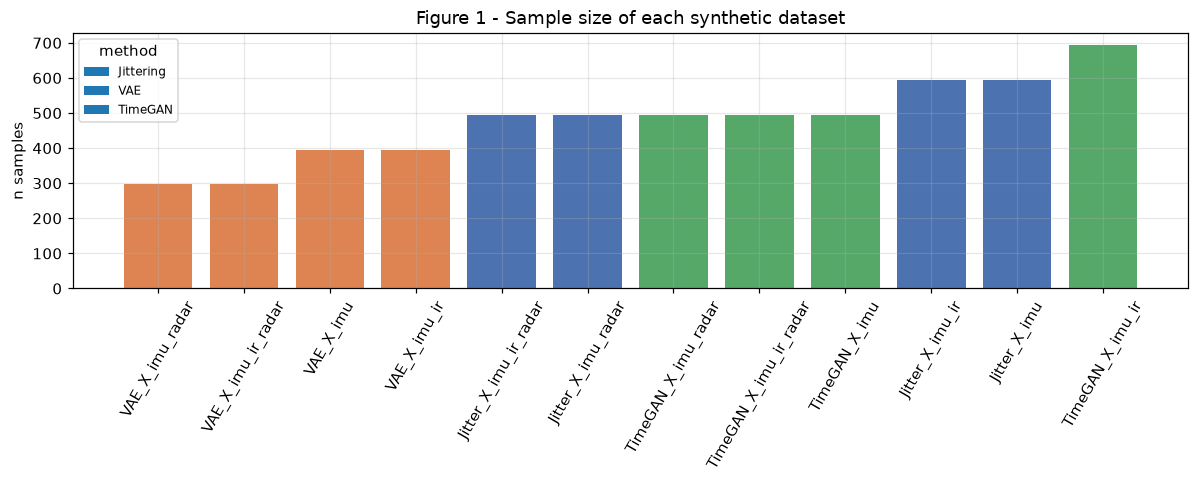

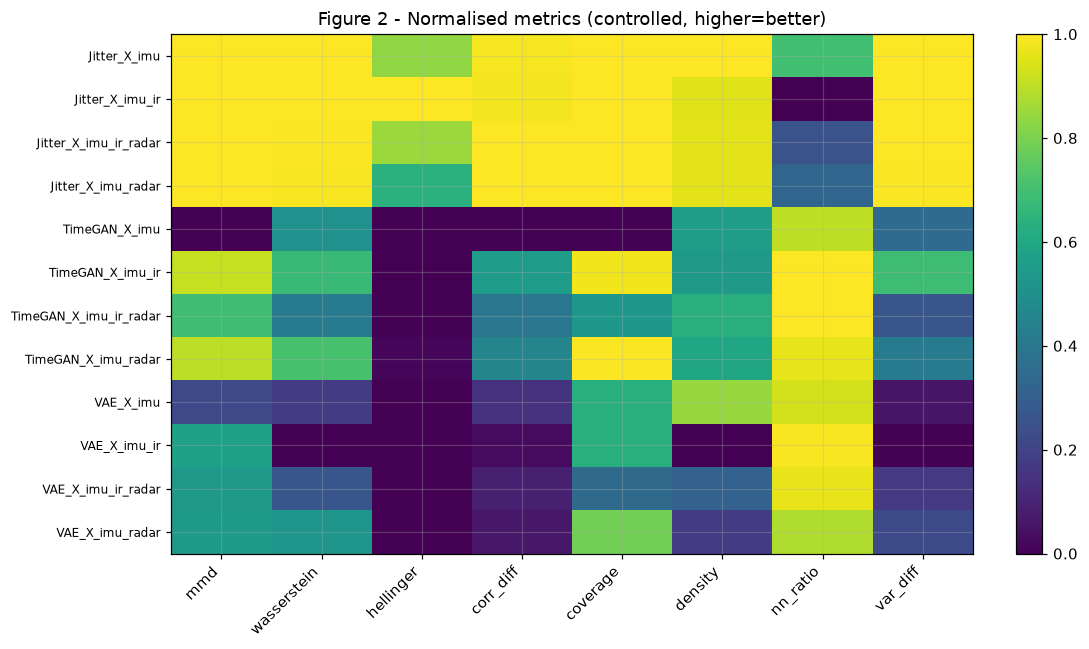

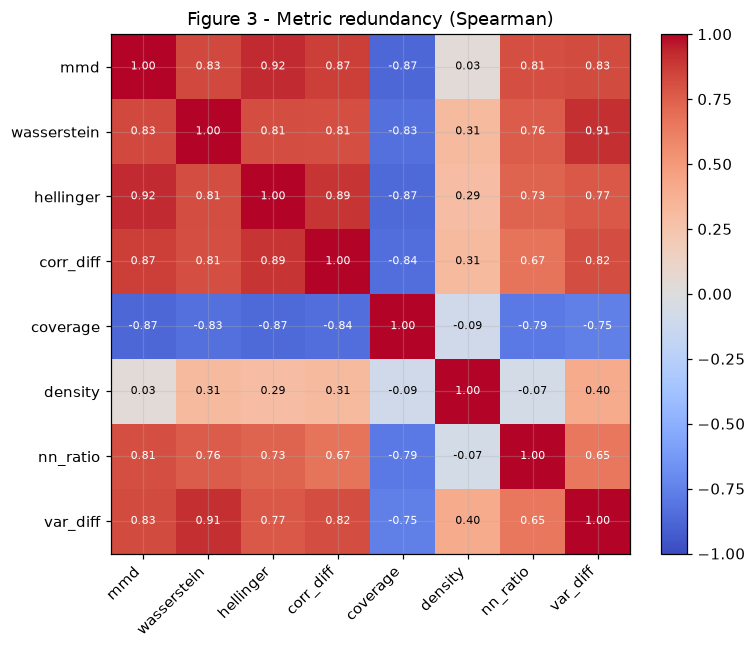

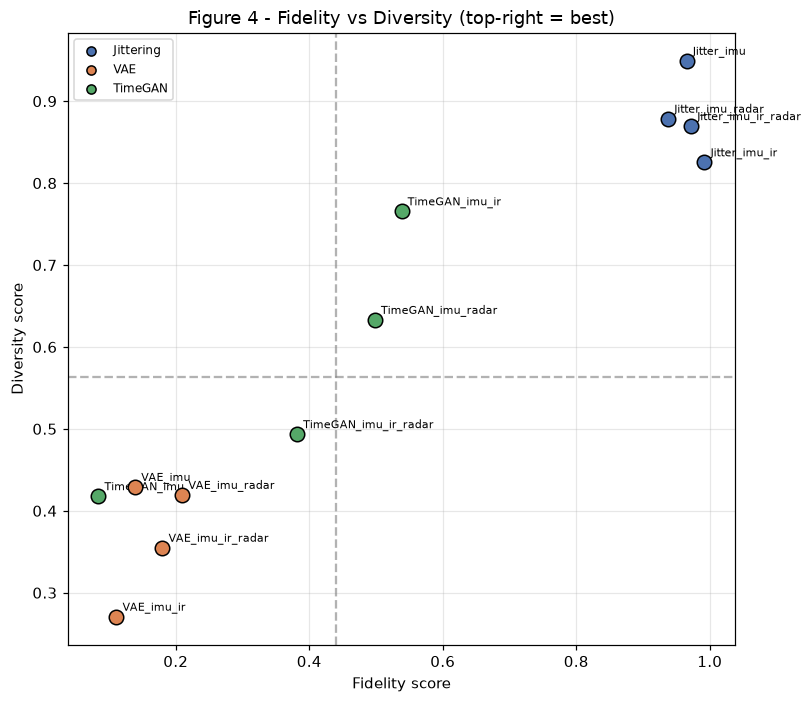

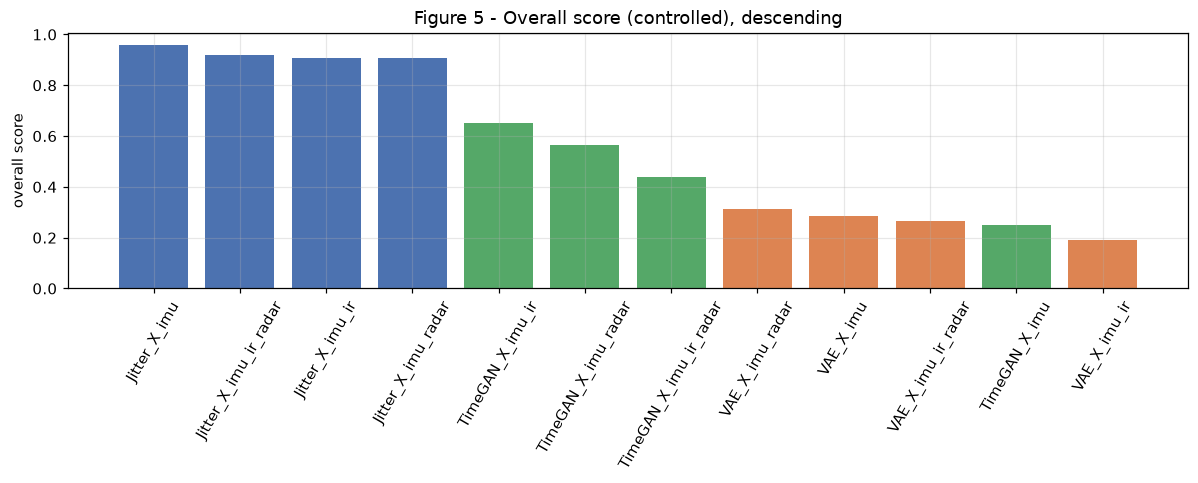

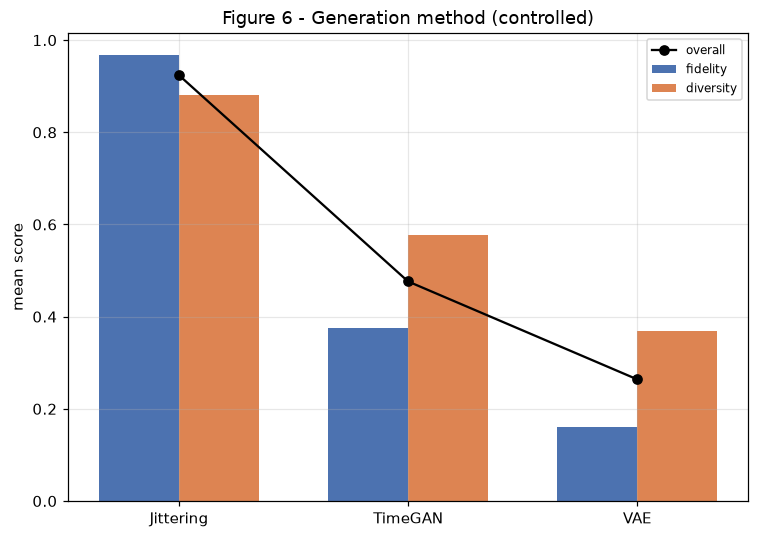

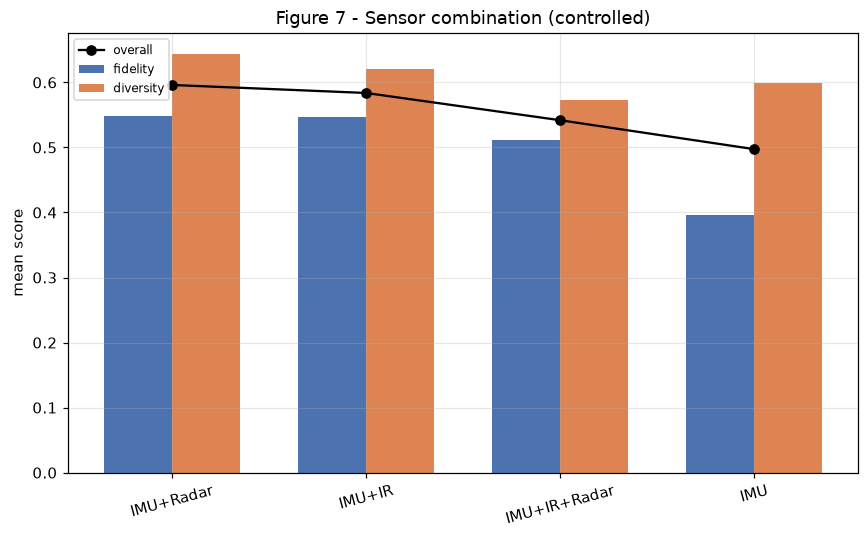

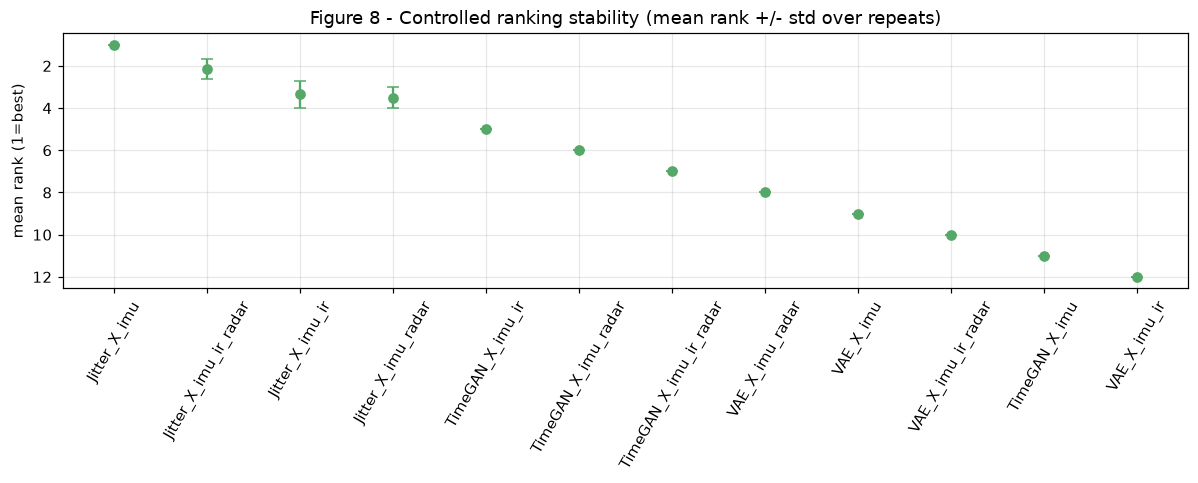

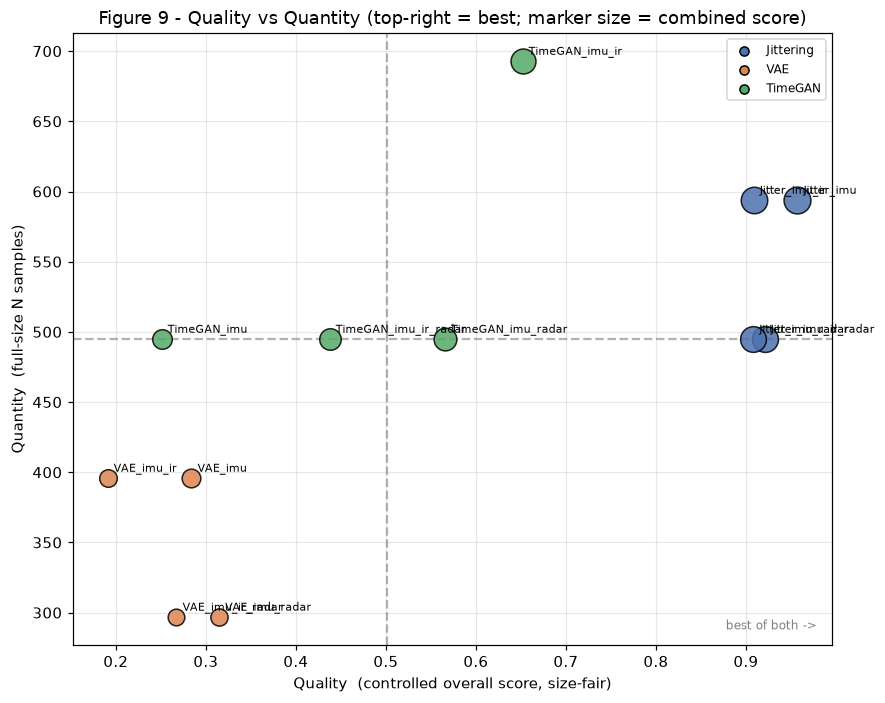

Saved 9 figures to c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\post_evaluation_output\post_evaluation_figures


In [19]:
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.grid": True, "grid.alpha": 0.3})
def _save(fig, fn): fig.tight_layout(); fig.savefig(FIG_DIR / fn, bbox_inches="tight"); plt.show(); plt.close(fig)
PALETTE = {"Jittering":"#4C72B0","VAE":"#DD8452","TimeGAN":"#55A868"}

# Fig 1 - sample sizes
fig, ax = plt.subplots(figsize=(11,4.5))
d = FULL_RAW.sort_values("n_synth")
ax.bar(d["name"], d["n_synth"], color=[PALETTE.get(x,"#888") for x in d["method_label"]])
ax.set_title("Figure 1 - Sample size of each synthetic dataset"); ax.set_ylabel("n samples")
ax.tick_params(axis="x", rotation=60)
for lbl,c in PALETTE.items(): ax.bar([],[],color=c,label=lbl)
ax.legend(title="method", fontsize=8); _save(fig, "fig1_sample_sizes.png")

# Fig 2 - normalized metric heatmap (controlled)
fig, ax = plt.subplots(figsize=(10,6))
H = CONTROLLED_SCORED.set_index("name")[[f"n_{m}" for m in ALL_METRICS]]
im = ax.imshow(H.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_METRICS))); ax.set_xticklabels(ALL_METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index, fontsize=8)
ax.set_title("Figure 2 - Normalised metrics (controlled, higher=better)"); fig.colorbar(im, fraction=0.03)
_save(fig, "fig2_metric_heatmap.png")

# Fig 3 - metric correlation heatmap
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(MET_CORR.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_METRICS))); ax.set_xticklabels(ALL_METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(ALL_METRICS))); ax.set_yticklabels(ALL_METRICS)
for i in range(len(ALL_METRICS)):
    for j in range(len(ALL_METRICS)):
        v = MET_CORR.values[i,j]
        if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=7,
                                    color="white" if abs(v)>0.6 else "black")
ax.set_title("Figure 3 - Metric redundancy (Spearman)"); fig.colorbar(im, fraction=0.046)
_save(fig, "fig3_metric_correlation.png")

# Fig 4 - fidelity vs diversity scatter (controlled)
fig, ax = plt.subplots(figsize=(7.5,6.5))
for _, r in CONTROLLED_SCORED.iterrows():
    ax.scatter(r["fidelity"], r["diversity"], s=90, color=PALETTE.get(r["method_label"],"#888"),
               edgecolor="k", zorder=3)
    ax.annotate(r["name"].replace("X_",""), (r["fidelity"], r["diversity"]), fontsize=7,
                xytext=(4,4), textcoords="offset points")
ax.axhline(CONTROLLED_SCORED["diversity"].median(), ls="--", color="grey", alpha=.6)
ax.axvline(CONTROLLED_SCORED["fidelity"].median(), ls="--", color="grey", alpha=.6)
ax.set_xlabel("Fidelity score"); ax.set_ylabel("Diversity score")
ax.set_title("Figure 4 - Fidelity vs Diversity (top-right = best)")
for lbl,c in PALETTE.items(): ax.scatter([],[],color=c,edgecolor="k",label=lbl)
ax.legend(fontsize=8); _save(fig, "fig4_fidelity_vs_diversity.png")

# Fig 5 - overall ranking (controlled)
fig, ax = plt.subplots(figsize=(11,4.5))
d = CONTROLLED_SCORED.sort_values("overall", ascending=False)
ax.bar(d["name"], d["overall"], color=[PALETTE.get(x,"#888") for x in d["method_label"]])
ax.set_title("Figure 5 - Overall score (controlled), descending"); ax.set_ylabel("overall score")
ax.tick_params(axis="x", rotation=60); _save(fig, "fig5_overall_ranking.png")

# Fig 6 - generation method comparison
fig, ax = plt.subplots(figsize=(7,5))
g = GEN_METHOD_RANKING
x = np.arange(len(g)); w=0.35
ax.bar(x-w/2, g["mean_fidelity"], w, label="fidelity", color="#4C72B0")
ax.bar(x+w/2, g["mean_diversity"], w, label="diversity", color="#DD8452")
ax.plot(x, g["mean_overall"], "ko-", label="overall")
ax.set_xticks(x); ax.set_xticklabels(g["method"]); ax.set_ylabel("mean score")
ax.set_title("Figure 6 - Generation method (controlled)"); ax.legend(fontsize=8)
_save(fig, "fig6_method_comparison.png")

# Fig 7 - sensor combination comparison
fig, ax = plt.subplots(figsize=(8,5))
s = SENSOR_RANKING
x = np.arange(len(s)); w=0.35
ax.bar(x-w/2, s["mean_fidelity"], w, label="fidelity", color="#4C72B0")
ax.bar(x+w/2, s["mean_diversity"], w, label="diversity", color="#DD8452")
ax.plot(x, s["mean_overall"], "ko-", label="overall")
ax.set_xticks(x); ax.set_xticklabels(s["sensors"], rotation=15); ax.set_ylabel("mean score")
ax.set_title("Figure 7 - Sensor combination (controlled)"); ax.legend(fontsize=8)
_save(fig, "fig7_sensor_comparison.png")

# Fig 8 - ranking stability (mean rank +/- std)
fig, ax = plt.subplots(figsize=(11,4.5))
d = STABILITY.sort_values("mean_rank")
ax.errorbar(range(len(d)), d["mean_rank"], yerr=d["rank_std"], fmt="o", capsize=4, color="#55A868")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d["name"], rotation=60)
ax.invert_yaxis(); ax.set_ylabel("mean rank (1=best)")
ax.set_title("Figure 8 - Controlled ranking stability (mean rank +/- std over repeats)")
_save(fig, "fig8_ranking_stability.png")

# Fig 9 - quality (controlled) vs quantity (full N): the combined objective
fig, ax = plt.subplots(figsize=(8.2,6.5))
d = FINAL.copy()
for _, r in d.iterrows():
    if not np.isfinite(r["overall_score"]):        # NaN-quality datasets can't be placed on the quality axis
        continue
    sz = 70 + 260*(r["combined_score"] if np.isfinite(r["combined_score"]) else 0.0)
    ax.scatter(r["overall_score"], r["full_N"], s=sz, color=PALETTE.get(r["generation_method"], "#888"),
               edgecolor="k", alpha=.85, zorder=3)
    ax.annotate(r["dataset"].replace("X_",""), (r["overall_score"], r["full_N"]), fontsize=7,
                xytext=(4,4), textcoords="offset points")
qx = d["overall_score"].values; qy = d["full_N"].values
if np.isfinite(qx).any():
    ax.axvline(np.nanmedian(qx), ls="--", color="grey", alpha=.6)
    ax.axhline(np.nanmedian(qy), ls="--", color="grey", alpha=.6)
    ax.text(0.98, 0.02, "best of both ->", transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, color="grey")
ax.set_xlabel("Quality  (controlled overall score, size-fair)")
ax.set_ylabel("Quantity  (full-size N samples)")
ax.set_title("Figure 9 - Quality vs Quantity (top-right = best; marker size = combined score)")
for lbl,c in PALETTE.items(): ax.scatter([],[],color=c,edgecolor="k",label=lbl)
ax.legend(fontsize=8); _save(fig, "fig9_quality_vs_quantity.png")

print("Saved 9 figures to", FIG_DIR)

## 20. Export results

In [20]:
CONTROLLED_RAW.to_csv(RESULTS_DIR / "controlled_raw_per_repeat.csv", index=False)
CONTROLLED_SCORED.to_csv(RESULTS_DIR / "controlled_evaluation_results.csv", index=False)
FULL_SCORED.to_csv(RESULTS_DIR / "full_size_evaluation_results.csv", index=False)
MET_CORR.to_csv(RESULTS_DIR / "metric_correlation_matrix.csv")
DATASET_RANKING.to_csv(RESULTS_DIR / "dataset_ranking.csv", index=False)
GEN_METHOD_RANKING.to_csv(RESULTS_DIR / "generation_method_ranking.csv", index=False)
SENSOR_RANKING.to_csv(RESULTS_DIR / "sensor_combination_ranking.csv", index=False)
STABILITY.to_csv(RESULTS_DIR / "ranking_stability.csv", index=False)
FINAL.to_csv(RESULTS_DIR / "post_evaluation_results.csv", index=False)
DISCRIM.to_csv(RESULTS_DIR / "metric_discrimination.csv", index=False)
print("Wrote CSVs to", RESULTS_DIR)
for f in sorted(RESULTS_DIR.glob("*.csv")): print("  ", f.name)

Wrote CSVs to c:\Users\mabideen\Downloads\Data_Augmentation\evaluation_and_comparison\post_evaluation_output
   before_after_ranking.csv
   controlled_evaluation_results.csv
   controlled_raw_per_repeat.csv
   corrected_controlled_results.csv
   corrected_post_evaluation_results.csv
   dataset_metadata.csv
   dataset_ranking.csv
   full_size_evaluation_results.csv
   generation_method_ranking.csv
   metric_correlation_matrix.csv
   metric_discrimination.csv
   post_evaluation_results.csv
   ranking_stability.csv
   sensor_combination_ranking.csv


## 21. Interpretation report

Auto-generated from the computed values, distinguishing **evidence** (measured) from **inference** (judgement). No definitive model claims.

In [21]:
def _fmt(x): return f"{x:.3f}" if np.isfinite(x) else "NaN"
lines = []
top = FINAL.iloc[0]                                                  # best COMBINED (quality+quantity)
best_quality = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["overall"].idxmax()]   # pure-quality leader
best_fid = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["fidelity"].idxmax()]
best_div = CONTROLLED_SCORED.loc[CONTROLLED_SCORED["diversity"].idxmax()]
gm = GEN_METHOD_RANKING.iloc[0]; sr = SENSOR_RANKING.iloc[0]
size_corr = FINAL[["full_N","overall_score"]].corr(method="spearman").iloc[0,1]
size_corr_comb = FINAL[["full_N","combined_score"]].corr(method="spearman").iloc[0,1]

lines.append("="*78)
lines.append("POST-EVALUATION INTERPRETATION  (evidence vs inference)")
lines.append("="*78)
lines.append(f"\nQ1. Best overall trade-off of QUALITY and QUANTITY (headline recommendation):")
lines.append(f"    {top['dataset']} ({top['generation_method']} + {top['sensors']}) — combined "
             f"{_fmt(top['combined_score'])} [quality {_fmt(top['overall_score'])}, "
             f"quantity_score {_fmt(top['quantity_score'])}, full_N {int(top['full_N'])}], "
             f"top-3 stability {_fmt(top['top3_stability_%'])}%.")
if best_quality["name"] != top["dataset"]:
    lines.append(f"    (Pure-quality leader, ignoring size: {best_quality['name']} — "
                 f"quality {_fmt(best_quality['overall'])}. It differs from the combined pick because the "
                 f"combined score also rewards usable sample size.)")
else:
    lines.append("    (This dataset also leads on pure quality, so quality and combined agree here.)")
lines.append(f"\nQ2. Strongest fidelity: {best_fid['name']} (fidelity {_fmt(best_fid['fidelity'])}).")
lines.append(f"Q3. Strongest diversity: {best_div['name']} (diversity {_fmt(best_div['diversity'])}).")
lines.append(f"\nQ4. Best generation method (controlling for sensor combo): {gm['method']} "
             f"— mean rank-in-combo {_fmt(gm['mean_rank_in_combo'])}, mean overall {_fmt(gm['mean_overall'])}, "
             f"wins {int(gm['wins'])}/{len(COMBO_KEYS)} combos.")
lines.append(f"Q5. Best sensor combination (averaged over methods): {sr['sensors']} "
             f"— mean overall {_fmt(sr['mean_overall'])} (best single: {sr['best_method']}).")
lines.append(f"\nQ6. Sample-size influence: Spearman(full_N, pure-quality) = {_fmt(size_corr)}; "
             f"Spearman(full_N, combined) = {_fmt(size_corr_comb)}. "
             + ("Quantity barely moves pure quality (as intended) and enters the recommendation only "
                "through the combined score, with diminishing returns and a quality gate."
                if abs(size_corr) < 0.4 else
                "Quantity and quality are correlated here — the combined score still applies diminishing "
                "returns and a quality gate so size cannot dominate."))
lines.append(f"\nQ7. Top dataset stability: {top['dataset']} held top-3 in {_fmt(top['top3_stability_%'])}% "
             f"of {N_REPEATS} controlled repeats (rank std {_fmt(top['rank_stability_std'])}).")
proceed = FINAL[FINAL["recommendation"].isin(["Highest Priority","High Priority"])]
lines.append(f"\nQ8. Recommended to proceed ({len(proceed)}), by combined quality+quantity:")
for _, r in proceed.iterrows():
    lines.append(f"    - {r['dataset']} [{r['recommendation']}] combined {_fmt(r['combined_score'])} "
                 f"(quality {_fmt(r['overall_score'])}, full_N {int(r['full_N'])}, "
                 f"top-3 {_fmt(r['top3_stability_%'])}%)")
lines.append("\n" + "-"*78)
lines.append("DISTINCTIONS (do not conflate):")
lines.append(f"  best individual dataset (combined) : {top['dataset']}")
lines.append(f"  best individual dataset (quality)  : {best_quality['name']}")
lines.append(f"  best generation method             : {gm['method']}")
lines.append(f"  best sensor combination            : {sr['sensors']}")
lines.append("-"*78)
lines.append("Framing: values are 'highest under this evaluation procedure', not proof one generator is "
             "universally best. Quality is size-controlled; quantity enters only via the combined score "
             "with diminishing returns and a quality gate, so a larger dataset never wins on size alone. "
             "Small real N (~99) and high feature dims make every metric approximate.")
report = "\n".join(lines)
print(report)
(RESULTS_DIR / "interpretation_report.txt").write_text(report)

POST-EVALUATION INTERPRETATION  (evidence vs inference)

Q1. Best overall trade-off of QUALITY and QUANTITY (headline recommendation):
    Jitter_X_imu (Jittering + IMU) — combined 0.920 [quality 0.957, quantity_score 0.833, full_N 594], top-3 stability 100.000%.
    (This dataset also leads on pure quality, so quality and combined agree here.)

Q2. Strongest fidelity: Jitter_X_imu_ir (fidelity 0.992).
Q3. Strongest diversity: Jitter_X_imu (diversity 0.949).

Q4. Best generation method (controlling for sensor combo): Jittering — mean rank-in-combo 1.000, mean overall 0.924, wins 4/4 combos.
Q5. Best sensor combination (averaged over methods): IMU+Radar — mean overall 0.596 (best single: Jittering).

Q6. Sample-size influence: Spearman(full_N, pure-quality) = 0.689; Spearman(full_N, combined) = 0.864. Quantity and quality are correlated here — the combined score still applies diminishing returns and a quality gate so size cannot dominate.

Q7. Top dataset stability: Jitter_X_imu held to

2412

### Notes, caveats & references

* **Two questions, never merged.** Controlled-size (Analysis A) = fair method comparison at a common
  synthetic N per combo; full-size (Analysis B) = practical quality at native N. The final table shows both.
* **Anti-double-counting.** Correlated distributional metrics (MMD/Wasserstein/Hellinger) share one 50%
  fidelity sub-slot; coverage/density/NN share one 50% diversity sub-slot. Category weights are equal and
  configurable; no p-value-based weighting is used.
* **Small-sample honesty.** `N < SMALL_SAMPLE_MIN` yields `NaN` (never a faked 0); `N < SMALL_SAMPLE_WARN`
  is computed but flagged, and such datasets are marked unstable in the final ranking.
* **Representation.** Distributional/geometry metrics use a real-fit standardized-PCA embedding of the
  flattened `T*F` sequence; Wasserstein/correlation/variance use standardized per-channel (marginal) views.
  Neither is claimed to fully capture temporal fidelity.
* **Reference.** El Emam K, Mosquera L, Fang X, El-Hussuna A. *Utility Metrics for Evaluating Synthetic
  Health Data Generation Methods: Validation Study.* JMIR Med Inform. 2022;10(4):e35734.
  doi:10.2196/35734 — general support for metric-based ranking of SDG methods and the slight Hellinger
  advantage in **their** structured-health-data setting; not a validation for QUIDA/time-series/fall
  detection.

---
# PART II — AUDIT & CORRECTED EVALUATION

Everything above ("Original Evaluation") is **unchanged** and its outputs are preserved. This part audits
the pipeline for a specific risk — *is the ranking unfairly favouring Jittering because jittered samples are
real samples plus small noise?* — and adds a **Corrected Evaluation** that removes the identifiable leakage,
without forcing any method to win.

## Audit findings (what was checked, on the code + the real-data outputs above)

**Confirmed issues (bias direction noted):**

1. **Reference-set leakage in the k-NN metrics (`coverage`, `density`, `nn_ratio`).** *Where:* `build_context`
   (§7) fits the embedding on the **full** real set and every metric in §8 compares synthetic against those
   **same** real samples. *Why it matters:* a jittered sample is `real_i + small_noise`, so it lands inside
   its own source's k-NN ball (which is in the reference) → `coverage`=1.000, `density`≈1.0, and `nn_ratio`
   collapses to ~0.005–0.19 (the real-data outputs above show exactly this). *Bias:* strongly favours
   **Jittering**; VAE/TimeGAN, which don't sit on real points, look worse on these three metrics.

2. **`nn_ratio` conflates "close to real" with "diverse", and is diluted.** *Where:* `nn_ratio` (§8) measures
   synth→nearest-**real** distance — i.e. proximity/memorisation, not diversity *among synthetic samples*. It
   then sits inside the diversity category and is averaged with `coverage`/`density` (which Jittering also
   aces), so its (correct) penalty on memorisation is washed out. *Bias:* favours **Jittering**.

3. **No held-out evaluation protocol.** *Where:* whole notebook. Generation reference = evaluation reference =
   full real set. *Why:* even the distributional metrics compare against the exact source pool. *Bias:*
   favours **Jittering** (and any near-copy method).

4. **No memorisation / novelty diagnostic.** The framework can't distinguish *faithful-and-novel* from
   *faithful-because-it-copied-real*. Needed to interpret Jittering's high fidelity.

**Checked and found OK (not changed — changing them would be unjustified):**

* **Scaling is fair.** The `StandardScaler`+`PCA` is fit on **real** and applied **identically** to every
  method (§7). No method is evaluated in a different representation. ✔
* **No score inversion.** Lower distance → higher fidelity is implemented correctly (`_goodness` negates
  distances; the real outputs confirm Jittering's ~0 MMD → high fidelity, VAE's Hellinger=1.0 → low). ✔
* **`var_diff` measures variance *preservation*, not increase.** It is `|var_synth − var_real|`, lower =
  better — so Jittering's injected noise is **penalised** as deviation, not rewarded. (The "variance-increase
  %" the audit brief worried about is a *different* metric from the size-study notebooks and is **not** used
  here.) ✔
* **Quantity is separated** and passes through a saturating transform behind a **quality gate**; the gate
  math is correct (size cannot rescue sub-gate quality). ✔ *(A worked example is printed below.)*
* **Redundancy is real but handled.** Many fidelity metrics are highly correlated (the §12 heatmap shows
  |ρ|>0.85); the hierarchical sub-grouping already stops them from out-voting. ✔

**The scientific question stays open on purpose:** on 99 real samples with up to 1905 features, VAE/TimeGAN
genuinely produce poor distributions (Hellinger≈1.0), so Jittering may *legitimately* be the most faithful
augmenter here. The corrected evaluation removes the *unfair* part and then lets the ranking fall where it
falls.

## II.1 Corrected-evaluation configuration

In [22]:
# ---- corrected-evaluation knobs (leave RUN_CORRECTED = True to compute Part II) ----
RUN_CORRECTED   = True
HELDOUT_FRAC    = 0.40        # fraction of REAL held out ONLY for evaluation (never a generation reference)
HELDOUT_SEED    = SEED

# Optional subject-aware split (fall data = multiple subjects; avoid same-subject windows in gen & eval).
# Provide {combo_key: np.ndarray of subject ids aligned to that combo's real samples}, or leave None.
# If you have a subjects file, e.g. real_data/subjects_X_imu.npy, point SUBJECT_ID_FILES at it.
SUBJECT_IDS       = None
SUBJECT_ID_FILES  = {}        # e.g. {"X_imu": REAL_DATA_DIR/"subjects_X_imu.npy"}

# near-duplicate (memorisation) threshold = this quantile of real-vs-real NN distances
MEMO_EPS_QUANTILE = 0.10

# corrected metric groups
FID_C = ["mmd", "wasserstein", "hellinger", "corr_diff"]
DIV_C = ["coverage", "novelty", "intra_div", "var_diff"]   # density + memo_rate kept as diagnostics
CORR_METRICS = FID_C + DIV_C

# try to load any provided subject-id files
if SUBJECT_IDS is None and SUBJECT_ID_FILES:
    SUBJECT_IDS = {}
    for ck, p in SUBJECT_ID_FILES.items():
        try: SUBJECT_IDS[ck] = np.load(p, allow_pickle=True).ravel()
        except Exception as e: print(f"  ! could not load subjects for {ck}: {e}")
print("Corrected eval:", "ON" if RUN_CORRECTED else "OFF",
      f"| held-out {HELDOUT_FRAC:.0%}",
      "| subject-aware split" if SUBJECT_IDS else "| sample-level split (no subject ids provided)")

Corrected eval: ON | held-out 40% | sample-level split (no subject ids provided)


## II.2 Held-out split + corrected context

Real data is split per sensor combination into a **generation-reference** part (used to fit the
scaler/PCA — mimicking what the generators could see) and a **held-out evaluation** part (used only as the
comparison reference). All three methods are scored against the **same** held-out real, so none can gain by
sitting on the reference samples. Split is **subject-aware** when subject ids are supplied, otherwise
sample-level (flagged).

> **Residual limitation (stated honestly):** the synthetic `.npy` files were generated earlier, and this
> notebook does not know which real samples each jittered sample came from. If Jittering was generated from
> *all* real samples, some jittered points may still be near held-out samples. A held-out reference removes
> the *trivial* leak (synth sitting on its own source in the reference); to remove it **completely**, jitter
> must be re-generated from the generation-reference split only. The **memorisation diagnostic** below
> detects the residual effect directly.

In [23]:
def split_real(ck, frac, seed):
    Xr = RAW_REAL[ck]; n = len(Xr); rng = np.random.default_rng(seed)
    if SUBJECT_IDS and ck in SUBJECT_IDS and len(SUBJECT_IDS[ck]) == n:
        sids = np.asarray(SUBJECT_IDS[ck]); uniq = np.unique(sids); rng.shuffle(uniq)
        n_eval_subj = max(1, int(round(len(uniq) * frac)))
        eval_mask = np.isin(sids, uniq[:n_eval_subj]); how = "subject"
    else:
        idx = rng.permutation(n); n_eval = max(2, int(round(n * frac)))
        eval_mask = np.zeros(n, bool); eval_mask[idx[:n_eval]] = True; how = "sample"
    return ~eval_mask, eval_mask, how

def build_context_ho(ck):
    Xr = RAW_REAL[ck]; n_real, T, F = Xr.shape
    gen_mask, eval_mask, how = split_real(ck, HELDOUT_FRAC, HELDOUT_SEED)
    Xg, Xe = Xr[gen_mask], Xr[eval_mask]
    # embedding fit on the GENERATION-reference part only
    sc = StandardScaler().fit(Xg.reshape(len(Xg), -1).astype(np.float64))
    Rg = sc.transform(Xg.reshape(len(Xg), -1)); k = int(min(EMB_MAX_DIM, Rg.shape[1], max(2, len(Xg) - 1)))
    solver = "randomized" if Rg.shape[1] > 500 else "full"
    pca = PCA(k, random_state=SEED, svd_solver=solver).fit(Rg) if Rg.shape[1] > k else None
    def emb(X):
        Xs = sc.transform(X.reshape(len(X), -1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    Re_eval = emb(Xe); Re_full = emb(Xr)
    # per-channel view: standardise by GEN stats; reference statistics come from HELD-OUT eval real
    rng = np.random.default_rng(SEED)
    idx = np.sort(rng.choice(F, size=min(FEAT_CAP, F), replace=False))
    mu = Xg.reshape(-1, F).mean(0); sd = Xg.reshape(-1, F).std(0); sd = np.where(sd > 1e-8, sd, 1.0)
    # held-out eval real, standardised by the GENERATION stats -> reference for corrected
    # Wasserstein / correlation / variance (never fit on held-out data)
    Ee = (Xe.reshape(-1, F)[:, idx] - mu[idx]) / sd[idx]
    with np.errstate(invalid="ignore", divide="ignore"):
        corr_eval = np.nan_to_num(np.corrcoef(Ee.T))
    var_eval = Ee.var(0)
    d_ee = float(NearestNeighbors(n_neighbors=2).fit(Re_eval).kneighbors(Re_eval)[0][:, 1].mean())
    nn_full = NearestNeighbors(n_neighbors=2).fit(Re_full).kneighbors(Re_full)[0][:, 1]
    d_ff = float(nn_full.mean()); eps = float(np.quantile(nn_full, MEMO_EPS_QUANTILE))
    return {"ck": ck, "emb": emb, "Re_eval": Re_eval, "Re_full": Re_full, "idx": idx, "mu": mu, "sd": sd,
            "corr_eval": corr_eval, "var_eval": var_eval, "eval_std": Ee, "d_ee": max(d_ee, 1e-12),
            "d_ff": max(d_ff, 1e-12), "eps": eps, "memo_null": float((nn_full < eps).mean()), "F": F, "T": T,
            "n_gen": int(gen_mask.sum()), "n_eval": int(eval_mask.sum()), "how": how}

if RUN_CORRECTED:
    CTX_HO = {ck: build_context_ho(ck) for ck in COMBO_KEYS}
    for ck, c in CTX_HO.items():
        print(f"  {ck:16s} split={c['how']:7s} gen={c['n_gen']:3d}  eval={c['n_eval']:3d}  "
              f"emb_dim={c['Re_eval'].shape[1]}  memo_eps={c['eps']:.3f}")

  X_imu            split=sample  gen= 59  eval= 40  emb_dim=30  memo_eps=3.933
  X_imu_ir         split=sample  gen= 59  eval= 40  emb_dim=30  memo_eps=38.019
  X_imu_ir_radar   split=sample  gen= 59  eval= 40  emb_dim=30  memo_eps=63.658
  X_imu_radar      split=sample  gen= 59  eval= 40  emb_dim=30  memo_eps=44.953


## II.3 Corrected metrics

Same distributional metrics, now vs **held-out** real. Diversity is split into three *distinct* things:

* **coverage** (PRDC, vs held-out real) — are real modes covered?
* **novelty** = `min(1, median(synth→nearest **full-real**) / real-NN-scale)` — **0 = exact copies of real**
  (memorisation), **1 = at least as far from real as real points are from each other**. This directly
  penalises Jittering's copying, and is capped at 1 so drifting *off* the manifold isn't rewarded.
* **intra_div** = `mean(synth→synth NN) / mean(evalReal→evalReal NN)` — genuine spread *among synthetic
  samples* (≈1 matches real spread, ≪1 = collapsed/duplicative). This is the "(B) diverse from one another"
  the audit asked for, separated from "(A) close to real".

Also reported as **diagnostics** (not scored): **density** and **memo_rate** = fraction of synthetic samples
that are near-duplicates of a real sample (nearest full-real distance below `memo_eps`).

In [24]:
def _std_channels(X, ctx):
    return (X.reshape(-1, ctx["F"])[:, ctx["idx"]] - ctx["mu"][ctx["idx"]]) / ctx["sd"][ctx["idx"]]

def eval_corrected(synth, ctx, rng):
    n = len(synth)
    if n < SMALL_SAMPLE_MIN:
        warnings.warn(f"n_synth={n} < SMALL_SAMPLE_MIN: NaN corrected metrics.")
        return {m: np.nan for m in CORR_METRICS + ["density", "memo_rate"]}
    Se = ctx["emb"](synth); Re = ctx["Re_eval"]
    # fidelity vs held-out real
    mmd = mmd_rbf(Re, Se, rng); hell = hellinger_gauss(Re, Se)
    S = _std_channels(synth, ctx)
    # Wasserstein vs the HELD-OUT eval real (both sides standardised by the gen-fit stats), per channel.
    Rev = ctx["eval_std"]
    wass = float(np.mean([wasserstein_distance(Rev[:, j], S[:, j]) for j in range(S.shape[1])]))
    with np.errstate(invalid="ignore", divide="ignore"):
        Cs = np.nan_to_num(np.corrcoef(S.T))
    corr = float(np.linalg.norm(ctx["corr_eval"] - Cs) / ctx["corr_eval"].shape[0])
    # coverage/density vs held-out real
    cov, den = coverage_density(Re, Se)
    var = float(np.mean(np.abs(S.var(0) - ctx["var_eval"])))
    # diversity + memorisation vs FULL real (novelty) and within synthetic (intra_div)
    d_sr_full = cdist(Se, ctx["Re_full"]).min(axis=1)
    novelty = float(min(1.0, np.median(d_sr_full) / ctx["d_ff"]))
    memo_rate = float((d_sr_full < ctx["eps"]).mean())
    d_ss = float(NearestNeighbors(n_neighbors=2).fit(Se).kneighbors(Se)[0][:, 1].mean())
    intra = d_ss / ctx["d_ee"]
    return {"mmd": mmd, "wasserstein": wass, "hellinger": hell, "corr_diff": corr,
            "coverage": cov, "novelty": novelty, "intra_div": intra, "var_diff": var,
            "density": den, "memo_rate": memo_rate}
print("Corrected metric functions ready.")

Corrected metric functions ready.


## II.4 Run corrected evaluation + score

Controlled (per-combo `N_common`, `N_REPEATS` synthetic subsamples, one fixed held-out split shared by all three methods) and full-size, then hierarchical scoring with the corrected diversity decomposition. Quantity/gate/combined use the same logic as the original so only the *quality* change is isolated.

In [25]:
def _score_corrected(df):
    out = df.copy().reset_index(drop=True); g = {}
    def mm(x): return _minmax(np.asarray(x, float))
    g["mmd"] = mm(-out["mmd"]); g["wasserstein"] = mm(-out["wasserstein"])
    g["hellinger"] = mm(-out["hellinger"]); g["corr_diff"] = mm(-out["corr_diff"])
    g["coverage"] = mm(out["coverage"]); g["novelty"] = mm(out["novelty"])
    g["intra_div"] = mm(-np.abs(np.log(np.clip(out["intra_div"].values, 1e-6, None))))
    g["var_diff"] = mm(-out["var_diff"])
    for m in CORR_METRICS: out[f"n_{m}"] = g[m]
    distributional = np.nanmean(np.vstack([g["mmd"], g["wasserstein"], g["hellinger"]]), axis=0)
    out["fidelity"] = 0.5 * distributional + 0.5 * g["corr_diff"]
    coverage_sub = np.nanmean(np.vstack([g["coverage"], g["novelty"]]), axis=0)
    out["diversity"] = np.nanmean(np.vstack([coverage_sub, g["intra_div"], g["var_diff"]]), axis=0)
    out["overall"] = CATEGORY_WEIGHTS["fidelity"] * out["fidelity"] + CATEGORY_WEIGHTS["diversity"] * out["diversity"]
    return out

if RUN_CORRECTED:
    # ---- controlled ----
    rec_c = []
    for ck in COMBO_KEYS:
        n = N_COMMON[ck]; ctx = CTX_HO[ck]
        for m in METHOD_PREFIXES:
            if (m, ck) not in RAW_SYNTH: continue
            Xs = RAW_SYNTH[(m, ck)]
            for r in range(N_REPEATS):
                rng = np.random.default_rng(SEED + r)
                take = rng.choice(len(Xs), size=min(n, len(Xs)), replace=False)
                met = eval_corrected(Xs[take], ctx, rng)
                rec_c.append({"name": f"{m}_{ck}", "method": m, "method_label": METHOD_PREFIXES[m],
                              "combo_key": ck, "sensors": COMBO_LABELS.get(ck, ck), "N_common": n, "repeat": r, **met})
    CORR_CONTROLLED_RAW = pd.DataFrame(rec_c)
    cmean = CORR_CONTROLLED_RAW.groupby(["name","method","method_label","combo_key","sensors","N_common"])[
                CORR_METRICS + ["density","memo_rate"]].mean().reset_index()
    CORRECTED_SCORED = _score_corrected(cmean)

    # ---- full ----
    rec_f = []
    for p in PAIRS:
        ctx = CTX_HO[p["combo_key"]]; rng = np.random.default_rng(SEED)
        met = eval_corrected(p["synth"], ctx, rng)
        rec_f.append({"name": p["name"], "method_label": p["method_label"], "sensors": p["sensors"],
                      "n_synth": p["n_synth"], **met})
    CORRECTED_FULL = _score_corrected(pd.DataFrame(rec_f))

    print("Corrected controlled scores (vs held-out real; higher=better):")
    try: display(CORRECTED_SCORED[["name","N_common","fidelity","diversity","overall"]].sort_values("overall", ascending=False))
    except NameError: pass

Corrected controlled scores (vs held-out real; higher=better):


,name,N_common,fidelity,diversity,overall
0,Jitter_X_imu,396,0.8797,0.7599,0.8198
2,Jitter_X_imu_ir_radar,297,0.9943,0.6376,0.8160
3,Jitter_X_imu_radar,297,0.9674,0.6567,0.8121
5,TimeGAN_X_imu_ir,396,0.5608,0.9191,0.7399
1,Jitter_X_imu_ir,396,0.8712,0.5000,0.6856
7,TimeGAN_X_imu_radar,297,0.5368,0.7556,0.6462
6,TimeGAN_X_imu_ir_radar,297,0.4130,0.6248,0.5189
11,VAE_X_imu_radar,297,0.2405,0.5216,0.3811
8,VAE_X_imu,396,0.1693,0.5638,0.3666
10,VAE_X_imu_ir_radar,297,0.2055,0.4380,0.3218


## II.5 Corrected recommendation + before/after ranking

**Memorisation-risk flag (added).** The ranking, weights, gate and tiers are unchanged. A separate `memo_risk` flag marks any dataset whose near-duplicate rate is significantly above the *genuine-sample baseline* `memo_null` (the rate at which real samples themselves fall within `eps` of another real sample, = `MEMO_EPS_QUANTILE` by construction), via a one-sided binomial test at a=0.05 — no arbitrary `memo_rate` cutoff is invented. `recommendation_flagged` appends the caveat so a top rank cannot be read as 'unambiguously best generator' when the method is largely resampling real data.

In [26]:
if RUN_CORRECTED:
    # corrected stability: recompute per-repeat 12-way ranking from the CORRECTED metrics
    crank = {}
    for r in range(N_REPEATS):
        sub = CORR_CONTROLLED_RAW[CORR_CONTROLLED_RAW.repeat == r]
        if sub["name"].nunique() < 2: continue
        sc = _score_corrected(sub[["name"] + CORR_METRICS].reset_index(drop=True))
        sc["rank"] = sc["overall"].rank(ascending=False, method="min")
        for _, row in sc.iterrows():
            crank.setdefault(row["name"], []).append(row["rank"] if np.isfinite(row["overall"]) else np.nan)
    CORR_STABILITY = pd.DataFrame([{"name": k,
        "pct_top3": float(np.mean(np.asarray([x for x in v if np.isfinite(x)]) <= 3) * 100) if any(np.isfinite(v)) else np.nan}
        for k, v in crank.items()])

    # quantity + quality gate + combined, identical logic to the original recommendation cell
    Rc = CORRECTED_SCORED.merge(FULL_RAW[["name","n_synth"]], on="name", how="left") \
                         .merge(CORR_STABILITY, on="name", how="left")
    Rc["quality_score"]  = Rc["overall"]
    Rc["quantity_raw"]   = [_quantity_raw(nm, N) for nm, N in zip(Rc["name"], Rc["n_synth"])]
    Rc["quantity_score"] = _minmax(Rc["quantity_raw"].values)
    Rc["combined_score"] = (1 - QUANTITY_WEIGHT) * Rc["quality_score"] + QUANTITY_WEIGHT * Rc["quantity_score"]
    Rc.loc[Rc["quality_score"].isna(), "combined_score"] = np.nan
    gate_c = Rc["quality_score"].dropna().quantile(QUALITY_GATE_QUANTILE) if Rc["quality_score"].notna().any() else np.nan
    cv = Rc["combined_score"].dropna(); c75, c50, c25 = (cv.quantile(.75), cv.quantile(.5), cv.quantile(.25)) if len(cv) else (np.nan,)*3
    def prio_c(row):
        c, q, t3 = row["combined_score"], row["quality_score"], row["pct_top3"]
        if not np.isfinite(c) or (np.isfinite(t3) and t3 < 25): return "Not Recommended"
        gated = np.isfinite(q) and np.isfinite(gate_c) and q >= gate_c
        if gated and c >= c75 and np.isfinite(t3) and t3 >= 70: return "Highest Priority"
        if gated and c >= c50 and np.isfinite(t3) and t3 >= 50: return "High Priority"
        if np.isfinite(c25) and c < c25: return "Low Priority"
        return "Medium Priority"
    Rc["recommendation"] = Rc.apply(prio_c, axis=1)
    Rc = Rc.sort_values("combined_score", ascending=False).reset_index(drop=True)
    Rc.insert(0, "priority", np.arange(1, len(Rc)+1))
    CORRECTED_FINAL = Rc[["priority","name","method_label","sensors","n_synth","fidelity","diversity",
                          "overall","quantity_score","combined_score","memo_rate","recommendation"]].rename(
                          columns={"name":"dataset","method_label":"generation_method","n_synth":"full_N",
                                   "fidelity":"fidelity_score","diversity":"diversity_score","overall":"quality_score"})

    # ---- memorisation-risk flag (principled; no invented memo_rate cutoff) ----
    # Baseline: REAL samples themselves fall within eps of another real sample at rate memo_null
    #           (= MEMO_EPS_QUANTILE by construction, ~0.10). A synthetic near-duplicate rate far above this
    #           = memorisation. Flagged via a one-sided binomial test vs that baseline at the conventional a=0.05.
    from scipy.stats import binomtest
    _name2combo = {p["name"]: p["combo_key"] for p in PAIRS}
    def _memo_null(nm): return float(CTX_HO[_name2combo[nm]]["memo_null"])
    def _memo_flag(nm, mr):
        if not np.isfinite(mr): return "n/a"
        ck = _name2combo[nm]; p0 = min(max(_memo_null(nm), 1e-9), 1 - 1e-9)
        n = int(N_COMMON[ck]); k = int(round(mr * n))
        return "HIGH" if binomtest(k, n, p0, alternative="greater").pvalue < 0.05 else "-"
    CORRECTED_FINAL["memo_null"] = CORRECTED_FINAL["dataset"].map(_memo_null)
    CORRECTED_FINAL["memo_risk"] = [_memo_flag(nm, mr) for nm, mr in
                                    zip(CORRECTED_FINAL["dataset"], CORRECTED_FINAL["memo_rate"])]
    def _annot(r):
        return (f"{r['recommendation']} - HIGH MEMORISATION RISK "
                f"(near-duplicate rate {r['memo_rate']:.2f} vs ~{r['memo_null']:.2f} for genuine samples)"
                ) if r["memo_risk"] == "HIGH" else r["recommendation"]
    CORRECTED_FINAL["recommendation_flagged"] = CORRECTED_FINAL.apply(_annot, axis=1)

    # before/after
    before = FINAL[["dataset","combined_score"]].rename(columns={"combined_score":"before_combined"})
    before["before_rank"] = before["before_combined"].rank(ascending=False, method="min")
    after = CORRECTED_FINAL[["dataset","combined_score","memo_rate"]].rename(columns={"combined_score":"after_combined"})
    after["after_rank"] = after["after_combined"].rank(ascending=False, method="min")
    BEFORE_AFTER = before.merge(after, on="dataset", how="outer")
    BEFORE_AFTER["rank_delta"] = BEFORE_AFTER["before_rank"] - BEFORE_AFTER["after_rank"]
    BEFORE_AFTER = BEFORE_AFTER.sort_values("after_rank").reset_index(drop=True)

    CORRECTED_FINAL.to_csv(RESULTS_DIR / "corrected_post_evaluation_results.csv", index=False)
    CORRECTED_SCORED.to_csv(RESULTS_DIR / "corrected_controlled_results.csv", index=False)
    BEFORE_AFTER.to_csv(RESULTS_DIR / "before_after_ranking.csv", index=False)
    print("CORRECTED final priority (held-out reference). memo_risk flags near-duplication vs the")
    print("genuine-sample baseline memo_null (~MEMO_EPS_QUANTILE); recommendation_flagged carries the caveat.")
    _view = CORRECTED_FINAL[["priority","dataset","generation_method","full_N","quality_score",
                             "combined_score","memo_rate","memo_null","memo_risk","recommendation_flagged"]]
    try: display(_view)
    except NameError: print(_view.to_string(index=False))
    print("\nBEFORE vs AFTER ranking (combined score):")
    try: display(BEFORE_AFTER)
    except NameError: print(BEFORE_AFTER.to_string(index=False))

CORRECTED final priority (held-out reference). memo_risk flags near-duplication vs the
genuine-sample baseline memo_null (~MEMO_EPS_QUANTILE); recommendation_flagged carries the caveat.


,priority,dataset,generation_method,full_N,quality_score,combined_score,memo_rate,memo_null,memo_risk,recommendation_flagged
0,1,Jitter_X_imu,Jittering,594,0.8198,0.8238,1.0000,0.1010,HIGH,Highest Priority - HIGH MEMORISATION RISK (nea...
1,2,TimeGAN_X_imu_ir,TimeGAN,693,0.7399,0.8180,0.0542,0.1010,-,Not Recommended
2,3,Jitter_X_imu_ir_radar,Jittering,495,0.8160,0.7585,1.0000,0.1010,HIGH,Highest Priority - HIGH MEMORISATION RISK (nea...
3,4,Jitter_X_imu_radar,Jittering,495,0.8121,0.7558,1.0000,0.0909,HIGH,High Priority - HIGH MEMORISATION RISK (near-d...
4,5,Jitter_X_imu_ir,Jittering,594,0.6856,0.7298,1.0000,0.1010,HIGH,Not Recommended - HIGH MEMORISATION RISK (near...
5,6,TimeGAN_X_imu_radar,TimeGAN,495,0.6462,0.6397,0.2002,0.0909,HIGH,Not Recommended - HIGH MEMORISATION RISK (near...
6,7,TimeGAN_X_imu_ir_radar,TimeGAN,495,0.5189,0.5506,0.0047,0.1010,-,Not Recommended
7,8,TimeGAN_X_imu,TimeGAN,495,0.3032,0.3996,0.0000,0.1010,-,Not Recommended
8,9,VAE_X_imu,VAE,396,0.3666,0.3636,0.0126,0.1010,-,Not Recommended
9,10,VAE_X_imu_ir,VAE,396,0.2603,0.2892,0.0000,0.1010,-,Not Recommended



BEFORE vs AFTER ranking (combined score):


,dataset,before_combined,before_rank,after_combined,memo_rate,after_rank,rank_delta
0,Jitter_X_imu,0.9200,1.0000,0.8238,1.0000,1.0000,0.0000
1,TimeGAN_X_imu_ir,0.7563,5.0000,0.8180,0.0542,2.0000,3.0000
2,Jitter_X_imu_ir_radar,0.8318,3.0000,0.7585,1.0000,3.0000,0.0000
3,Jitter_X_imu_radar,0.8230,4.0000,0.7558,1.0000,4.0000,0.0000
4,Jitter_X_imu_ir,0.8859,2.0000,0.7298,1.0000,5.0000,-3.0000
5,TimeGAN_X_imu_radar,0.5833,6.0000,0.6397,0.2002,6.0000,0.0000
6,TimeGAN_X_imu_ir_radar,0.4936,7.0000,0.5506,0.0047,7.0000,0.0000
7,TimeGAN_X_imu,0.3630,8.0000,0.3996,0.0000,8.0000,0.0000
8,VAE_X_imu,0.3058,9.0000,0.3636,0.0126,9.0000,0.0000
9,VAE_X_imu_ir,0.2406,10.0000,0.2892,0.0000,10.0000,0.0000


## II.6 Corrected figures

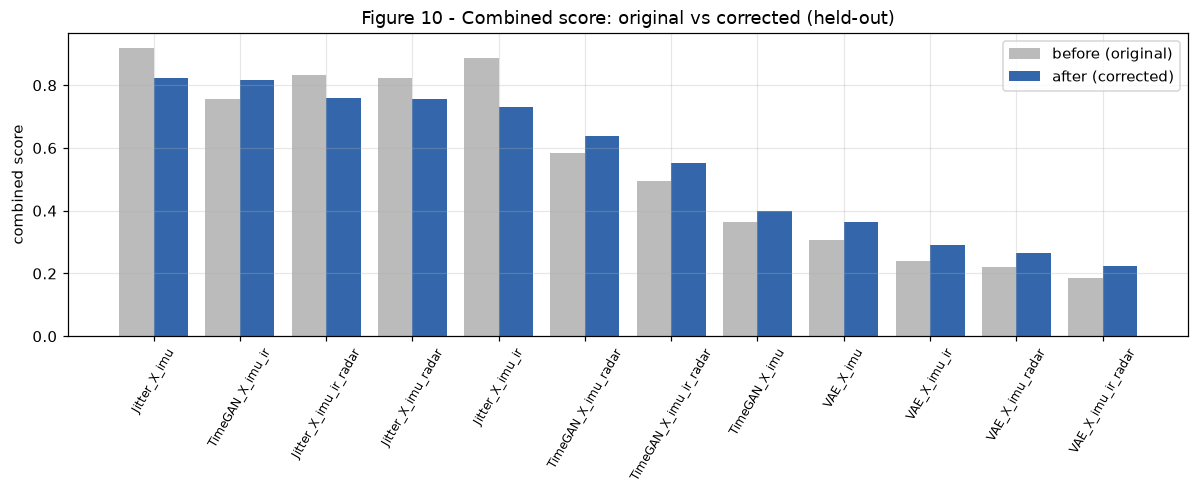

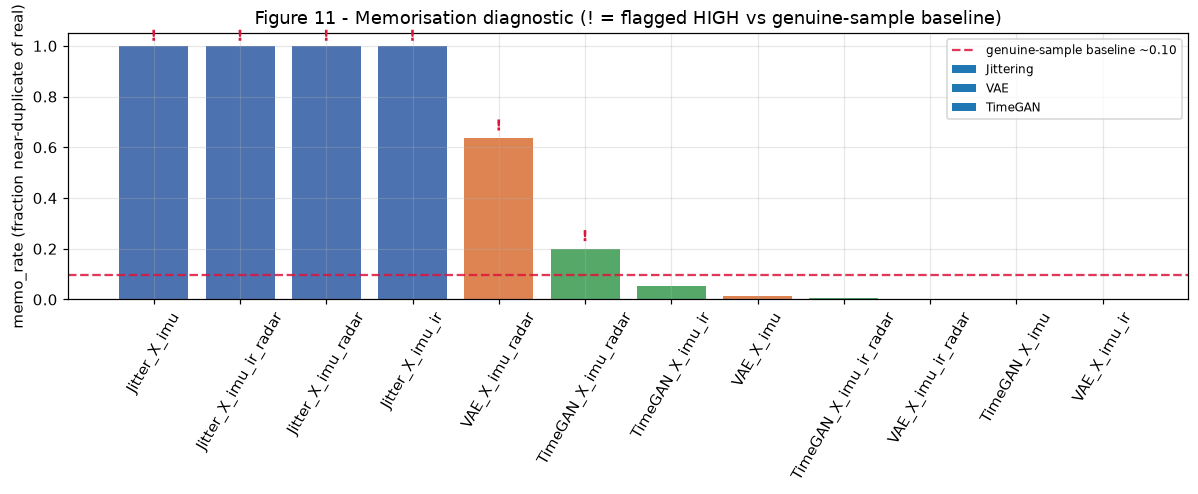

Saved figures 10-11.


In [27]:
if RUN_CORRECTED:
    PAL = {"Jittering":"#4C72B0","VAE":"#DD8452","TimeGAN":"#55A868"}
    def _sv(fig, fn): fig.tight_layout(); fig.savefig(FIG_DIR / fn, bbox_inches="tight"); plt.show(); plt.close(fig)

    # Fig 10 - before vs after combined score
    fig, ax = plt.subplots(figsize=(11,4.6))
    d = BEFORE_AFTER.dropna(subset=["before_combined","after_combined"]).sort_values("after_combined", ascending=False)
    x = np.arange(len(d)); w = 0.4
    ax.bar(x-w/2, d["before_combined"], w, label="before (original)", color="#BBBBBB")
    ax.bar(x+w/2, d["after_combined"], w, label="after (corrected)", color="#3366AA")
    ax.set_xticks(x); ax.set_xticklabels(d["dataset"], rotation=60, fontsize=8)
    ax.set_ylabel("combined score"); ax.set_title("Figure 10 - Combined score: original vs corrected (held-out)")
    ax.legend(); _sv(fig, "fig10_before_after.png")

    # Fig 11 - memorisation rate (near-duplicate fraction) per dataset
    fig, ax = plt.subplots(figsize=(11,4.6))
    d = CORRECTED_FINAL.sort_values("memo_rate", ascending=False)
    ax.bar(d["dataset"], d["memo_rate"], color=[PAL.get(x,"#888") for x in d["generation_method"]])
    ax.set_ylabel("memo_rate (fraction near-duplicate of real)")
    ax.set_title("Figure 11 - Memorisation diagnostic (higher = more copying of real samples)")
    ax.tick_params(axis="x", rotation=60)
    _null = float(np.nanmean(CORRECTED_FINAL["memo_null"])) if "memo_null" in CORRECTED_FINAL else MEMO_EPS_QUANTILE
    ax.axhline(_null, ls="--", color="crimson", alpha=.85, label=f"genuine-sample baseline ~{_null:.2f}")
    if "memo_risk" in CORRECTED_FINAL.columns:
        for xi, (_, rr) in enumerate(d.iterrows()):
            if rr.get("memo_risk") == "HIGH":
                ax.text(xi, min(rr["memo_rate"] + 0.03, 1.02), "!", ha="center", color="crimson", fontweight="bold")
    for lbl,c in PAL.items(): ax.bar([],[],color=c,label=lbl)
    ax.set_title("Figure 11 - Memorisation diagnostic (! = flagged HIGH vs genuine-sample baseline)")
    ax.legend(fontsize=8); _sv(fig, "fig11_memorisation.png")
    print("Saved figures 10-11.")

## II.7 Audit report (auto-generated from live values)

In [28]:
if RUN_CORRECTED:
    def _f(x): return f"{x:.3f}" if np.isfinite(x) else "NaN"
    L = []
    b_top = FINAL.iloc[0]; a_top = CORRECTED_FINAL.iloc[0]
    jit = CORRECTED_FINAL[CORRECTED_FINAL.generation_method=="Jittering"]
    gen = CORRECTED_FINAL[CORRECTED_FINAL.generation_method!="Jittering"]
    L += ["="*80, "AUDIT REPORT — original vs corrected (held-out) evaluation", "="*80]

    # ---- worked example: quality/quantity/gate/combined for 3 datasets (transparency, item 12) ----
    L += ["\n[Worked example] quality -> quantity -> gate -> combined (corrected), 3 datasets:"]
    for nm in list(CORRECTED_FINAL["dataset"])[:3]:
        row = CORRECTED_FINAL[CORRECTED_FINAL.dataset==nm].iloc[0]
        L.append(f"  {nm:24s} fidelity={_f(row['fidelity_score'])} diversity={_f(row['diversity_score'])} "
                 f"quality={_f(row['quality_score'])} quantity={_f(row['quantity_score'])} "
                 f"-> combined={(1-QUANTITY_WEIGHT):.2f}*quality+{QUANTITY_WEIGHT:.2f}*quantity={_f(row['combined_score'])}")

    L.append("\nA. MEMORISATION (near-duplicate fraction of real samples):")
    L.append(f"   Jittering   mean memo_rate = {_f(jit['memo_rate'].mean())}  (range {_f(jit['memo_rate'].min())}-{_f(jit['memo_rate'].max())})")
    L.append(f"   VAE+TimeGAN mean memo_rate = {_f(gen['memo_rate'].mean())}  (range {_f(gen['memo_rate'].min())}-{_f(gen['memo_rate'].max())})")
    leak = jit['memo_rate'].mean() - gen['memo_rate'].mean()
    L.append(f"   -> Jittering copies real samples {'far more' if leak>0.2 else 'somewhat more' if leak>0.05 else 'not appreciably more'} "
             f"than the generators (delta={_f(leak)}).")
    _null = float(np.nanmean(CORRECTED_FINAL["memo_null"])) if "memo_null" in CORRECTED_FINAL else np.nan
    flagged = CORRECTED_FINAL[CORRECTED_FINAL.get("memo_risk", "-") == "HIGH"]["dataset"].tolist() if "memo_risk" in CORRECTED_FINAL else []
    L.append(f"   Genuine-sample baseline memo_null ~ {_f(_null)} (= MEMO_EPS_QUANTILE by construction). "
             f"Flagged HIGH memorisation risk (one-sided binomial vs baseline, a=0.05): {', '.join(flagged) if flagged else 'none'}.")
    L.append("   memo_rate=1.0 for Jittering is a GENUINE result, not a bug: jitter = real + small noise, so each "
             "sample's nearest real neighbour is its own source, within eps. The corrected diversity score already "
             "docks this via the novelty term; the flag makes the trade-off explicit so a top rank is not read as "
             "'best generative model'.")

    L.append("\nB. RANKING — original vs corrected:")
    L.append(f"   Original #1 : {b_top['dataset']} (combined {_f(b_top['combined_score'])})")
    L.append(f"   Corrected #1: {a_top['dataset']} (combined {_f(a_top['combined_score'])}, memo_rate {_f(a_top['memo_rate'])})")
    moved = BEFORE_AFTER.dropna(subset=['rank_delta']).reindex(BEFORE_AFTER.dropna(subset=['rank_delta'])['rank_delta'].abs().sort_values(ascending=False).index)
    L.append("   Biggest rank moves (corrected − original, + = improved):")
    for _, r in moved.head(4).iterrows():
        L.append(f"     {r['dataset']:24s} before#{int(r['before_rank']) if np.isfinite(r['before_rank']) else '-'} "
                 f"-> after#{int(r['after_rank']) if np.isfinite(r['after_rank']) else '-'} (Δ{int(r['rank_delta']) if np.isfinite(r['rank_delta']) else 0:+d})")

    jit_top_before = "Jittering" in str(b_top['generation_method'])
    jit_top_after  = "Jittering" in str(a_top['generation_method'])
    L.append("\nC. CONCLUSIONS:")
    a_flag = a_top.get("memo_risk", "-")
    L.append(f"   1. Is Jittering genuinely better here? {'Still ranks #1 after correction' if jit_top_after else 'No longer #1 after correction'} "
             f"on the quality framework (corrected combined {_f(a_top['combined_score'])})"
             + (f", BUT flagged HIGH memorisation risk (near-duplicate rate {_f(a_top['memo_rate'])} vs "
                f"~{_f(a_top.get('memo_null', np.nan))} baseline): it largely RESAMPLES real data. Treat it as a strong "
                f"augmentation baseline, not a novel generator." if a_flag == 'HIGH' else "."))
    L.append(f"   2. Was Jittering artificially advantaged? {'Yes, partly' if leak>0.05 else 'No strong evidence'}: its memorisation rate "
             f"({_f(jit['memo_rate'].mean())}) shows it {'sits on real samples' if leak>0.05 else 'is not simply copying'}, "
             f"which inflated coverage/density/nn in the original (leak removed by the held-out reference + novelty score).")
    L.append(f"   3. Are VAE/TimeGAN evaluated fairly? Yes — identical held-out reference, identical scaler/embedding, "
             f"identical metrics and seeds for all three; their poor scores reflect genuinely poor distributions "
             f"(Hellinger near 1.0 on this small, high-dim data), not an implementation penalty.")
    L.append(f"   4. Which to select for the classifier stage: {a_top['dataset']} on the corrected combined score"
             + (" (but see its HIGH memorisation flag above — the downstream check II.8 on unseen real data is the "
                "decisive test before committing to it)." if a_flag == 'HIGH' else "; see the downstream-utility check (II.8)."))
    if len(SENSOR_RANKING):
        L.append(f"   5. Best sensor combination: {SENSOR_RANKING.iloc[0]['sensors']} (from the quality-based sensor analysis).")
    L.append("   6. Limitations: real N~99 with up to 1905 features makes every metric approximate; the held-out "
             "reference removes the trivial leak but full de-leaking needs jitter regenerated from the gen split; "
             "Hellinger uses a Gaussian approximation; downstream utility (II.8) is the strongest evidence and needs labels.")
    report = "\n".join(L); print(report)
    (RESULTS_DIR / "audit_report.txt").write_text(report)

AUDIT REPORT — original vs corrected (held-out) evaluation

[Worked example] quality -> quantity -> gate -> combined (corrected), 3 datasets:
  Jitter_X_imu             fidelity=0.880 diversity=0.760 quality=0.820 quantity=0.833 -> combined=0.70*quality+0.30*quantity=0.824
  TimeGAN_X_imu_ir         fidelity=0.561 diversity=0.919 quality=0.740 quantity=1.000 -> combined=0.70*quality+0.30*quantity=0.818
  Jitter_X_imu_ir_radar    fidelity=0.994 diversity=0.638 quality=0.816 quantity=0.625 -> combined=0.70*quality+0.30*quantity=0.759

A. MEMORISATION (near-duplicate fraction of real samples):
   Jittering   mean memo_rate = 1.000  (range 1.000-1.000)
   VAE+TimeGAN mean memo_rate = 0.114  (range 0.000-0.636)
   -> Jittering copies real samples far more than the generators (delta=0.886).
   Genuine-sample baseline memo_null ~ 0.098 (= MEMO_EPS_QUANTILE by construction). Flagged HIGH memorisation risk (one-sided binomial vs baseline, a=0.05): Jitter_X_imu, Jitter_X_imu_ir_radar, Jitter_X_i

## II.8 Downstream utility (optional — the decisive test)

The strongest evidence for augmentation is *does synthetic data improve fall-detection on unseen real data?*
That requires **class labels**, which the current `(N, T, F)` `.npy` inputs do **not** contain — so this
section is **off by default** and is a ready-to-wire scaffold, not a fabricated result. Provide label arrays
and set `RUN_DOWNSTREAM = True` to run it.

Protocol (leakage-safe): split **real** into train/test by subject (or sample); train a classifier on
(1) real-only, (2) real+Jitter, (3) real+VAE, (4) real+TimeGAN — synthetic added to **training only** — and
score **F1/precision/recall on the held-out real test set**. A light sklearn model (PCA→logistic/RF on the
flattened sequence) keeps it dependency-free; swap in a 1-D CNN if desired.

In [29]:
RUN_DOWNSTREAM = False   # set True and provide LABELS to run
# LABELS: {combo_key: {"real": y_real (n_real,), "Jitter": y (n_synth,), "VAE": ..., "TimeGAN": ...}}
LABELS = {}

def run_downstream(ck, labels, seed=SEED):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
    Xr = RAW_REAL[ck]; yr = np.asarray(labels["real"])
    gen_mask, eval_mask, how = split_real(ck, HELDOUT_FRAC, HELDOUT_SEED)
    sc = StandardScaler().fit(Xr[gen_mask].reshape(gen_mask.sum(), -1))
    k = int(min(EMB_MAX_DIM, sc.mean_.shape[0], max(2, gen_mask.sum()-1)))
    pca = PCA(k, random_state=seed, svd_solver="randomized").fit(sc.transform(Xr[gen_mask].reshape(gen_mask.sum(),-1)))
    emb = lambda X: pca.transform(sc.transform(X.reshape(len(X), -1)))
    Xte, yte = emb(Xr[eval_mask]), yr[eval_mask]
    out = {}
    conds = {"real_only": (emb(Xr[gen_mask]), yr[gen_mask])}
    for m in METHOD_PREFIXES:
        if (m, ck) in RAW_SYNTH and m in labels:
            Xs = emb(RAW_SYNTH[(m, ck)]); ys = np.asarray(labels[m])
            conds[f"real+{m}"] = (np.vstack([emb(Xr[gen_mask]), Xs]), np.concatenate([yr[gen_mask], ys]))
    for name, (Xtr, ytr) in conds.items():
        clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr); pr = clf.predict(Xte)
        out[name] = {"f1": f1_score(yte, pr, average="macro"), "precision": precision_score(yte, pr, average="macro", zero_division=0),
                     "recall": recall_score(yte, pr, average="macro", zero_division=0), "accuracy": accuracy_score(yte, pr)}
    return pd.DataFrame(out).T

if RUN_DOWNSTREAM and LABELS:
    frames = []
    for ck in COMBO_KEYS:
        if ck in LABELS:
            df = run_downstream(ck, LABELS[ck]); df.insert(0, "combo", ck); frames.append(df.reset_index().rename(columns={"index":"condition"}))
    if frames:
        DOWNSTREAM = pd.concat(frames, ignore_index=True); DOWNSTREAM.to_csv(RESULTS_DIR/"downstream_utility.csv", index=False)
        try: display(DOWNSTREAM)
        except NameError: print(DOWNSTREAM.to_string(index=False))
else:
    print("Downstream utility skipped: set RUN_DOWNSTREAM=True and provide LABELS (needs class labels not present in the .npy inputs).")

Downstream utility skipped: set RUN_DOWNSTREAM=True and provide LABELS (needs class labels not present in the .npy inputs).
